# 01 — Exploratory Data Analysis

Our task is to explore the electricity and gas data and prepare it for a first fraud-classification model.

We will look at the two tables, check whether the data makes sense, and create one row per client for later modelling. The invoice table is large, so it is processed in chunks instead of loading everything at once.

Run the notebook from top to bottom. Stop at the discussion prompts, talk through them with your group, and write down what you notice. The data is read from Parquet files; the optional output is a smaller CSV with one row per client.

## Business Case

Imagine that a utility company has a small team that can inspect only some clients. We want to help them decide which clients to inspect first.

- We will start with **average precision**, which summarises the precision-recall curve, as our main metric.
- We will also look at **precision** and **recall**. We will use a `k`, which means the number of clients the team can inspect.
- Later, we can also use ROC-AUC, a confusion matrix, and results for different groups of clients.

Before choosing a final model, we ask: 
- How many inspections are possible?
- What does an inspection cost?
- What is the cost of missing fraud or falsely accusing a customer?
These answers help us choose a `k` and a prediction threshold later.

For now, use the charts to ask good questions. A difference between fraud and non-fraud clients does not automatically explain why fraud happens.

### Notebook's workflow
```text
raw client/invoice files
        ↓
ClientFeatureBuilder
        ↓
aggregate_invoices
aggregate_meter_submissions
audit_meter_reconciliation
        ↓
select the 15 agreed features
        ↓
impute missing values
        ↓
scale numeric features
        ↓
one-hot encode categories
        ↓
model-ready data
´´´

## Imports and constants

In the next cell we import the libraries used in this notebook and define the file locations and settings. CHUNK_SIZE controls how many invoice rows are handled at one time. This notebook performs EDA and creates one complete labelled training feature table; it does not split the data. The modelling notebook can create its own evaluation split from that table.

Local settings can also be changed outside the notebook in .env. Copy .env.example to .env if it does not already exist. The notebook loads that file without overwriting environment variables already set by Docker or GitHub Actions.

In [131]:
import os
from dotenv import find_dotenv, load_dotenv
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pyarrow.parquet as pq
from IPython.display import display


# Find the repository's .env even when Jupyter starts with a different working directory.
dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    # In local Jupyter, .env is authoritative; in CI, injected variables stay authoritative.
    load_dotenv(dotenv_path, override=os.getenv("CI", "").lower() != "true")
    REPO_ROOT = Path(dotenv_path).parent
    print(f"Loaded environment from: {dotenv_path}")
else:
    # CI deliberately does not contain the ignored .env file.
    REPO_ROOT = Path.cwd()
    print("No .env file found; using environment variables supplied by the shell or CI.")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

DATA_DIR = REPO_ROOT / "data"
PARQUET_DIR = DATA_DIR / "parquet"
CHUNK_SIZE = 250_000
# The default is false. Set SAVE_TRAINING_ARTIFACTS=true in .env to save the training table and pipeline artifact.
# CI passes this setting directly, which takes priority over .env.
SAVE_TRAINING_ARTIFACTS = os.getenv("SAVE_TRAINING_ARTIFACTS", "false").lower() == "true"
AS_OF_DATE = None  # Example: "2018-12-31"; required for a real deployment backtest.
RSEED = 42

required_files = [PARQUET_DIR / "client_train.parquet", PARQUET_DIR / "invoice_train.parquet"]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required files: {missing_files}.")

print(f"SAVE_TRAINING_ARTIFACTS={SAVE_TRAINING_ARTIFACTS}")
print(f"Using Parquet data from: {PARQUET_DIR.resolve()}")

Loaded environment from: /home/jovyan/work/week_08/ds-fraud-in-electricity-and-gas/.env
SAVE_TRAINING_ARTIFACTS=True
Using Parquet data from: /home/jovyan/work/week_08/ds-fraud-in-electricity-and-gas/data/parquet


## Step 1 - Understand the data

`client_train.parquet` has one row per client and contains the target. `invoice_train.parquet` has many invoices for each client. Before we model, we need to understand how these tables fit together.

The relationship is **one client to many invoices**. Client columns describe the customer. Invoice columns describe readings and consumption over time. For our first model, we turn the invoices into summaries for each client, for example: number of invoices, average consumption, zero-consumption rate, and whether the invoices are electricity or gas.

### Load all labelled clients

This cell loads the complete labelled client_train table and checks its basic shape. We use client directly for the early exploration. Later, client_features will mean the feature-enriched client table. No train/test split is made in this EDA notebook; the final output is one complete df_training table.

In [132]:
client = pd.read_parquet(PARQUET_DIR / "client_train.parquet")
client["client_id"] = client["client_id"].astype("string")
client["creation_date"] = pd.to_datetime(client["creation_date"], dayfirst=True, errors="raise")
client["target"] = client["target"].astype("int8")

client_overview = pd.DataFrame({
    "rows": [len(client)],
    "unique_clients": [client["client_id"].nunique()],
    "duplicate_rows": [client.duplicated().sum()],
    "missing_cells": [int(client.isna().sum().sum())],
    "fraud_rate": [client["target"].mean()],
})
display(client_overview)
display(client.head())
display(client.dtypes.rename("dtype").to_frame())

assert client["client_id"].is_unique, "Expected one row per client."
assert set(client["target"].unique()) <= {0, 1}, "Target must be binary."

,rows,unique_clients,duplicate_rows,missing_cells,fraud_rate
0,135493,135493,0,0,0.055841


,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0
1,69,train_Client_1,11,107,2002-05-29,0
2,62,train_Client_10,11,301,1986-03-13,0
3,69,train_Client_100,11,105,1996-07-11,0
4,62,train_Client_1000,11,303,2014-10-14,0


,dtype
disrict,int16
client_id,string
client_catg,int16
region,int16
creation_date,datetime64[us]
target,int8


### Missing values in all client rows

This check uses the complete `client` table. A zero means that column has no missing values. This is a raw-data check: it tells us whether values are empty (`NaN`), but it does not tell us whether a value is unusual or unrealistic.

In [133]:
# Check for missing values in the complete client data
# This happens before EDA, so we see the real state of the supplied data.
display(client.isna().sum().rename("missing_values").to_frame())

,missing_values
disrict,0
client_id,0
client_catg,0
region,0
creation_date,0
target,0


### Check the labelled target

This shows the number of labelled clients and the fraud/non-fraud counts used by the EDA. No rows have been held out at this stage.

In [134]:
print(f"Labelled clients used for EDA: {len(client):,}")
display(pd.crosstab(client["target"], columns="clients", margins=True))

Labelled clients used for EDA: 135,493


col_0,clients,All
target,,
0,127927,127927
1,7566,7566
All,135493,135493


## Step 2 - EDA Part

### Check for missing values

The source column names `disrict` and `counter_statue` are misspelled. We keep them as they are so that the notebook matches the supplied data.

The code below reads the complete invoice file in smaller batches. This matters because there are millions of invoices and loading all of them at once can crash a notebook kernel.

### First look at invoice rows

The full invoice table is too large to display. This cell reads a small sample so we can see the column names, example values, and data types. `counter_statue` and `counter_type` are text categories: they describe a status or meter type, not an amount that can sensibly be averaged.

In [135]:
invoice_parquet = pq.ParquetFile(PARQUET_DIR / "invoice_train.parquet")
invoice_sample = invoice_parquet.read_row_group(0).to_pandas().head(5_000)
invoice_sample["invoice_date"] = pd.to_datetime(invoice_sample["invoice_date"], errors="raise")
display(invoice_sample.head())
display(invoice_sample.dtypes.rename("inferred_dtype").to_frame())
print(f"Sample shape: {invoice_sample.shape}")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


,inferred_dtype
client_id,str
invoice_date,datetime64[us]
tarif_type,int16
counter_number,int64
counter_statue,str
counter_code,int16
reading_remarque,int16
counter_coefficient,int16
consommation_level_1,int64
consommation_level_2,int64


Sample shape: (5000, 16)


### Create one row per client

The next cell defines a function; it does not run the full calculation yet. The function reads every invoice in small batches and builds client summaries such as invoice count, first and last invoice date, consumption totals, zero-consumption rate, electricity/gas share, and the average/longest gap between invoices. It also counts missing values across the complete invoice table.

We need this because the target is stored once per client, while the invoice table has many rows per client. A model needs one consistent row per client.

In [136]:
CONSUMPTION_COLUMNS = [f"consommation_level_{level}" for level in range(1, 5)]

def aggregate_invoices(path, chunk_size=250_000, as_of_date=None):
    partials = []
    row_hashes = []
    missing_counts = None
    status_counts = pd.Series(dtype="int64")
    tariff_counts = pd.Series(dtype="int64")
    source_rows = 0
    total_rows = 0
    excluded_after_cutoff = 0
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None
    started = time.perf_counter()

    parquet_file = pq.ParquetFile(path)
    reader = parquet_file.iter_batches(batch_size=chunk_size)

    for chunk_number, batch in enumerate(reader, start=1):
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        source_rows += len(chunk)
        # Count missing values before any optional date filtering.
        # This is the missing-value check for the complete invoice data.
        chunk_missing = chunk.isna().sum()
        missing_counts = chunk_missing if missing_counts is None else missing_counts.add(chunk_missing, fill_value=0)
        if cutoff is not None:
            after_cutoff = chunk["invoice_date"].gt(cutoff)
            excluded_after_cutoff += int(after_cutoff.sum())
            chunk = chunk.loc[~after_cutoff].copy()
        total_rows += len(chunk)
        row_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())
        status_counts = status_counts.add(chunk["counter_statue"].value_counts(), fill_value=0)
        tariff_counts = tariff_counts.add(chunk["tarif_type"].value_counts(), fill_value=0)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["zero_consumption"] = chunk["total_consumption"].eq(0).astype("int8")
        chunk["is_elec"] = chunk["counter_type"].eq("ELEC").astype("int8")
        chunk["is_gaz"] = chunk["counter_type"].eq("GAZ").astype("int8")
        chunk["index_went_backwards"] = chunk["index_delta"].lt(0).astype("int8")
        # months_number is the billing-period length. Values above 24 are implausible here,
        # so exclude them only from the per-month calculation, not from the raw data.
        chunk["valid_billing_months"] = chunk["months_number"].between(1, 24)
        chunk["billed_months"] = chunk["months_number"].where(chunk["valid_billing_months"])
        chunk["index_delta_for_valid_months"] = chunk["index_delta"].where(chunk["valid_billing_months"])
        chunk["is_four_month_bill"] = chunk["months_number"].eq(4).astype("int8")

        grouped = chunk.groupby("client_id", observed=True).agg(
            invoice_count=("client_id", "size"),
            first_invoice=("invoice_date", "min"),
            last_invoice=("invoice_date", "max"),
            total_consumption_sum=("total_consumption", "sum"),
            total_consumption_max=("total_consumption", "max"),
            index_delta_sum=("index_delta", "sum"),
            index_delta_min=("index_delta", "min"),
            index_delta_max=("index_delta", "max"),
            months_sum=("months_number", "sum"),
            zero_consumption_count=("zero_consumption", "sum"),
            elec_invoice_count=("is_elec", "sum"),
            gaz_invoice_count=("is_gaz", "sum"),
            backwards_index_count=("index_went_backwards", "sum"),
            valid_billing_invoice_count=("valid_billing_months", "sum"),
            billed_months_sum=("billed_months", "sum"),
            index_delta_valid_months_sum=("index_delta_for_valid_months", "sum"),
            four_month_bill_count=("is_four_month_bill", "sum"),
        )
        partials.append(grouped.reset_index())
        if chunk_number % 5 == 0:
            print(f"Processed {total_rows:,} invoice rows...")

    partial = pd.concat(partials, ignore_index=True)
    client_agg = partial.groupby("client_id", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        first_invoice=("first_invoice", "min"),
        last_invoice=("last_invoice", "max"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        total_consumption_max=("total_consumption_max", "max"),
        index_delta_sum=("index_delta_sum", "sum"),
        index_delta_min=("index_delta_min", "min"),
        index_delta_max=("index_delta_max", "max"),
        months_sum=("months_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
        elec_invoice_count=("elec_invoice_count", "sum"),
        gaz_invoice_count=("gaz_invoice_count", "sum"),
        backwards_index_count=("backwards_index_count", "sum"),
        valid_billing_invoice_count=("valid_billing_invoice_count", "sum"),
        billed_months_sum=("billed_months_sum", "sum"),
        index_delta_valid_months_sum=("index_delta_valid_months_sum", "sum"),
        four_month_bill_count=("four_month_bill_count", "sum"),
    )

    # Calculate date gaps for each client. Invoice rows are stored together
    # by client in this Parquet file, so only one client's dates need to be
    # kept in memory at a time.
    gap_rows = []
    closed_client_ids = set()
    current_client_id = None
    current_date_parts = []

    def finish_current_client():
        if current_client_id is None:
            return
        dates = np.sort(np.concatenate(current_date_parts))
        if len(dates) < 2:
            gap_rows.append({
                "client_id": current_client_id,
                "invoice_gap_count": 0,
                "mean_invoice_gap_days": 0.0,
                "max_invoice_gap_days": 0,
            })
            return
        gap_days = np.diff(dates).astype("timedelta64[D]").astype(int)
        gap_rows.append({
            "client_id": current_client_id,
            "invoice_gap_count": len(gap_days),
            "mean_invoice_gap_days": gap_days.mean(),
            "max_invoice_gap_days": gap_days.max(),
        })

    gap_reader = pq.ParquetFile(path).iter_batches(
        batch_size=chunk_size,
        columns=["client_id", "invoice_date"],
    )
    for gap_batch in gap_reader:
        gap_frame = gap_batch.to_pandas()
        gap_frame["invoice_date"] = pd.to_datetime(gap_frame["invoice_date"], errors="raise")
        for client_id, group in gap_frame.groupby("client_id", sort=False):
            client_dates = group["invoice_date"].dropna().to_numpy(dtype="datetime64[ns]")
            if current_client_id is None:
                current_client_id = client_id
                current_date_parts = [client_dates]
            elif client_id == current_client_id:
                current_date_parts.append(client_dates)
            else:
                finish_current_client()
                closed_client_ids.add(current_client_id)
                if client_id in closed_client_ids:
                    raise ValueError("Invoice rows are not grouped by client; cannot calculate gaps safely.")
                current_client_id = client_id
                current_date_parts = [client_dates]
    finish_current_client()

    gap_features = pd.DataFrame(gap_rows)
    client_agg = client_agg.merge(gap_features, on="client_id", how="left", validate="one_to_one")

    client_agg["mean_consumption"] = client_agg["total_consumption_sum"] / client_agg["invoice_count"]
    client_agg["mean_index_delta"] = client_agg["index_delta_sum"] / client_agg["invoice_count"]
    client_agg["mean_months"] = client_agg["months_sum"] / client_agg["invoice_count"]
    client_agg["zero_consumption_rate"] = client_agg["zero_consumption_count"] / client_agg["invoice_count"]
    client_agg["elec_share"] = client_agg["elec_invoice_count"] / client_agg["invoice_count"]
    client_agg["active_days"] = (client_agg["last_invoice"] - client_agg["first_invoice"]).dt.days
    client_agg["backwards_index_rate"] = client_agg["backwards_index_count"] / client_agg["invoice_count"]
    client_agg["mean_index_delta_per_billed_month"] = np.where(
        client_agg["billed_months_sum"].gt(0),
        client_agg["index_delta_valid_months_sum"] / client_agg["billed_months_sum"],
        np.nan,
    )
    client_agg["mean_billing_months"] = np.where(
        client_agg["valid_billing_invoice_count"].gt(0),
        client_agg["billed_months_sum"] / client_agg["valid_billing_invoice_count"],
        np.nan,
    )
    client_agg["four_month_bill_rate"] = client_agg["four_month_bill_count"] / client_agg["invoice_count"]
    client_agg["invoice_frequency_per_year"] = np.where(
        client_agg["active_days"].gt(0),
        client_agg["invoice_count"] / (client_agg["active_days"] / 365.25),
        0,
    )

    invoice_hashes = pd.Series(np.concatenate(row_hashes), copy=False)
    duplicate_row_hashes = invoice_hashes[invoice_hashes.duplicated(keep=False)].unique()
    audit = {
        "source_invoice_rows": source_rows,
        "invoice_rows": total_rows,
        "excluded_after_cutoff": excluded_after_cutoff,
        "duplicate_row_hash_matches": int(invoice_hashes.duplicated().sum()),
        "duplicate_row_hashes": duplicate_row_hashes,
        "invoice_clients": client_agg["client_id"].nunique(),
        "missing_by_column": missing_counts.sort_values(ascending=False),
        "counter_status_counts": status_counts.sort_index().astype("int64"),
        "tariff_counts": tariff_counts.sort_index().astype("int64"),
        "elapsed_seconds": time.perf_counter() - started,
    }
    return client_agg, audit

### Run the invoice aggregation

This is the longer-running cell. It processes every invoice, prints progress, and then shows the missing-value count for the complete invoice data. It also shows the values found in `counter_statue` and `tarif_type`. A result of zero missing values is useful, but still check unusual categories and extreme values later.

In [137]:
invoice_features, invoice_audit = aggregate_invoices(
    PARQUET_DIR / "invoice_train.parquet",
    chunk_size=CHUNK_SIZE,
    as_of_date=AS_OF_DATE,
)

print(f"Processed {invoice_audit['invoice_rows']:,} rows in {invoice_audit['elapsed_seconds']:.1f}s")
print("Missing values in the complete invoice data:")
display(invoice_features.head())
display(invoice_audit["missing_by_column"].rename("missing_values").to_frame())
display(invoice_audit["counter_status_counts"].rename("invoice_rows").to_frame())
display(invoice_audit["tariff_counts"].rename("invoice_rows").to_frame())

Processed 1,250,000 invoice rows...
Processed 2,500,000 invoice rows...
Processed 3,750,000 invoice rows...
Processed 4,476,749 rows in 16.4s
Missing values in the complete invoice data:


,client_id,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,valid_billing_invoice_count,billed_months_sum,index_delta_valid_months_sum,four_month_bill_count,invoice_gap_count,mean_invoice_gap_days,max_invoice_gap_days,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days,backwards_index_rate,mean_index_delta_per_billed_month,mean_billing_months,four_month_bill_rate,invoice_frequency_per_year
0,train_Client_0,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,35,162.0,12704.0,30,34,144.147059,508,362.971429,362.971429,4.628571,0.0,1.0,4901,0.0,78.419753,4.628571,0.857143,2.608396
1,train_Client_1,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,37,160.0,20629.0,31,36,136.472222,372,557.540541,557.540541,4.324324,0.0,1.0,4913,0.0,128.931250,4.324324,0.837838,2.750712
2,train_Client_10,18,2005-11-10,2019-05-02,15057,3082,15057,188,3082,116,0,18,0,0,18,116.0,15057.0,11,17,289.470588,738,836.5,836.5,6.444444,0.0,1.0,4921,0.0,129.801724,6.444444,0.611111,1.336009
3,train_Client_100,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,20,84.0,24.0,18,19,140.210526,442,1.2,1.2,4.2,0.8,1.0,2664,0.0,0.285714,4.200000,0.9,2.742117
4,train_Client_1000,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,14,52.0,12917.0,12,13,121.923077,301,922.642857,922.642857,3.714286,0.0,1.0,1585,0.0,248.403846,3.714286,0.857143,3.226183


,missing_values
client_id,0
invoice_date,0
tarif_type,0
counter_number,0
counter_statue,0
counter_code,0
reading_remarque,0
counter_coefficient,0
consommation_level_1,0
consommation_level_2,0


,invoice_rows
counter_statue,
0,4379008
1,74036
2,32
269375,1
3,258
4,2729
420,1
46,14
5,20639


,invoice_rows
tarif_type,
8,43
9,6039
10,276210
11,2679872
12,11345
13,11656
14,11611
15,72422
18,4


### Add invoice summaries to all labelled clients

This cell joins the client-level invoice summaries onto every labelled client. The checks show whether every invoice client belongs to the client table and whether any client has no invoices. `merge` creates a new DataFrame, so it does not change `client`. The resulting `client_features` is the feature-enriched client table used for the remaining EDA.

In [138]:
unknown_invoice_clients = set(invoice_features["client_id"]) - set(client["client_id"])
clients_without_invoices = set(client["client_id"]) - set(invoice_features["client_id"])
print(f"Invoice clients absent from client table: {len(unknown_invoice_clients):,}")
print(f"Clients without invoices: {len(clients_without_invoices):,}")

# `merge` returns a new table, so `client` remains unchanged and this cell is safe to re-run.
# Add one invoice-summary row to each labelled client.
client_features = client.merge(
    invoice_features,
    on="client_id",
    how="left",
    validate="one_to_one",
)
# Calculate customer tenure after merging because creation_date comes from client data and last_invoice comes from invoice data.
client_features["customer_tenure_days_at_last_invoice"] = (
    client_features["last_invoice"] - client_features["creation_date"]
).dt.days

assert len(client_features) == len(client)
assert not unknown_invoice_clients
display(client_features.head())
print(f"The EDA below uses all {len(client_features):,} labelled clients.")

Invoice clients absent from client table: 0
Clients without invoices: 0


,disrict,client_id,client_catg,region,creation_date,target,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,valid_billing_invoice_count,billed_months_sum,index_delta_valid_months_sum,four_month_bill_count,invoice_gap_count,mean_invoice_gap_days,max_invoice_gap_days,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days,backwards_index_rate,mean_index_delta_per_billed_month,mean_billing_months,four_month_bill_rate,invoice_frequency_per_year,customer_tenure_days_at_last_invoice
0,60,train_Client_0,11,101,1994-12-31,0,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,35,162.0,12704.0,30,34,144.147059,508,362.971429,362.971429,4.628571,0.0,1.0,4901,0.0,78.419753,4.628571,0.857143,2.608396,8844
1,69,train_Client_1,11,107,2002-05-29,0,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,37,160.0,20629.0,31,36,136.472222,372,557.540541,557.540541,4.324324,0.0,1.0,4913,0.0,128.931250,4.324324,0.837838,2.750712,6152
2,62,train_Client_10,11,301,1986-03-13,0,18,2005-11-10,2019-05-02,15057,3082,15057,188,3082,116,0,18,0,0,18,116.0,15057.0,11,17,289.470588,738,836.5,836.5,6.444444,0.0,1.0,4921,0.0,129.801724,6.444444,0.611111,1.336009,12103
3,69,train_Client_100,11,105,1996-07-11,0,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,20,84.0,24.0,18,19,140.210526,442,1.2,1.2,4.2,0.8,1.0,2664,0.0,0.285714,4.200000,0.9,2.742117,5920
4,62,train_Client_1000,11,303,2014-10-14,0,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,14,52.0,12917.0,12,13,121.923077,301,922.642857,922.642857,3.714286,0.0,1.0,1585,0.0,248.403846,3.714286,0.857143,3.226183,1707


The EDA below uses all 135,493 labelled clients.


## Step 3 - Data Exploration

We explore the complete labelled client_features from here on. The EDA creates a single client-level training table; a model-evaluation split belongs in the modelling notebook, after this table is loaded.

### Skewness of the features

Some clients have much larger consumption than others. We use a log scale in the charts so that those very large values do not hide the rest of the data. If you see a useful difference, ask whether that information would really be available before an inspection takes place.

### Look at the feature distributions

This cell makes one histogram for each client-level feature using `client_features`. Blue is non-fraud and red is fraud, so we can compare the two groups directly. The values are shown on a log scale because consumption, invoice counts, and invoice gaps are very uneven. Fraud is drawn with a stronger, less transparent line because it is the much smaller group. Look for long tails, many zero values, and features where the red shape differs from the blue shape. The table underneath compares the median and mean for fraud and non-fraud clients.

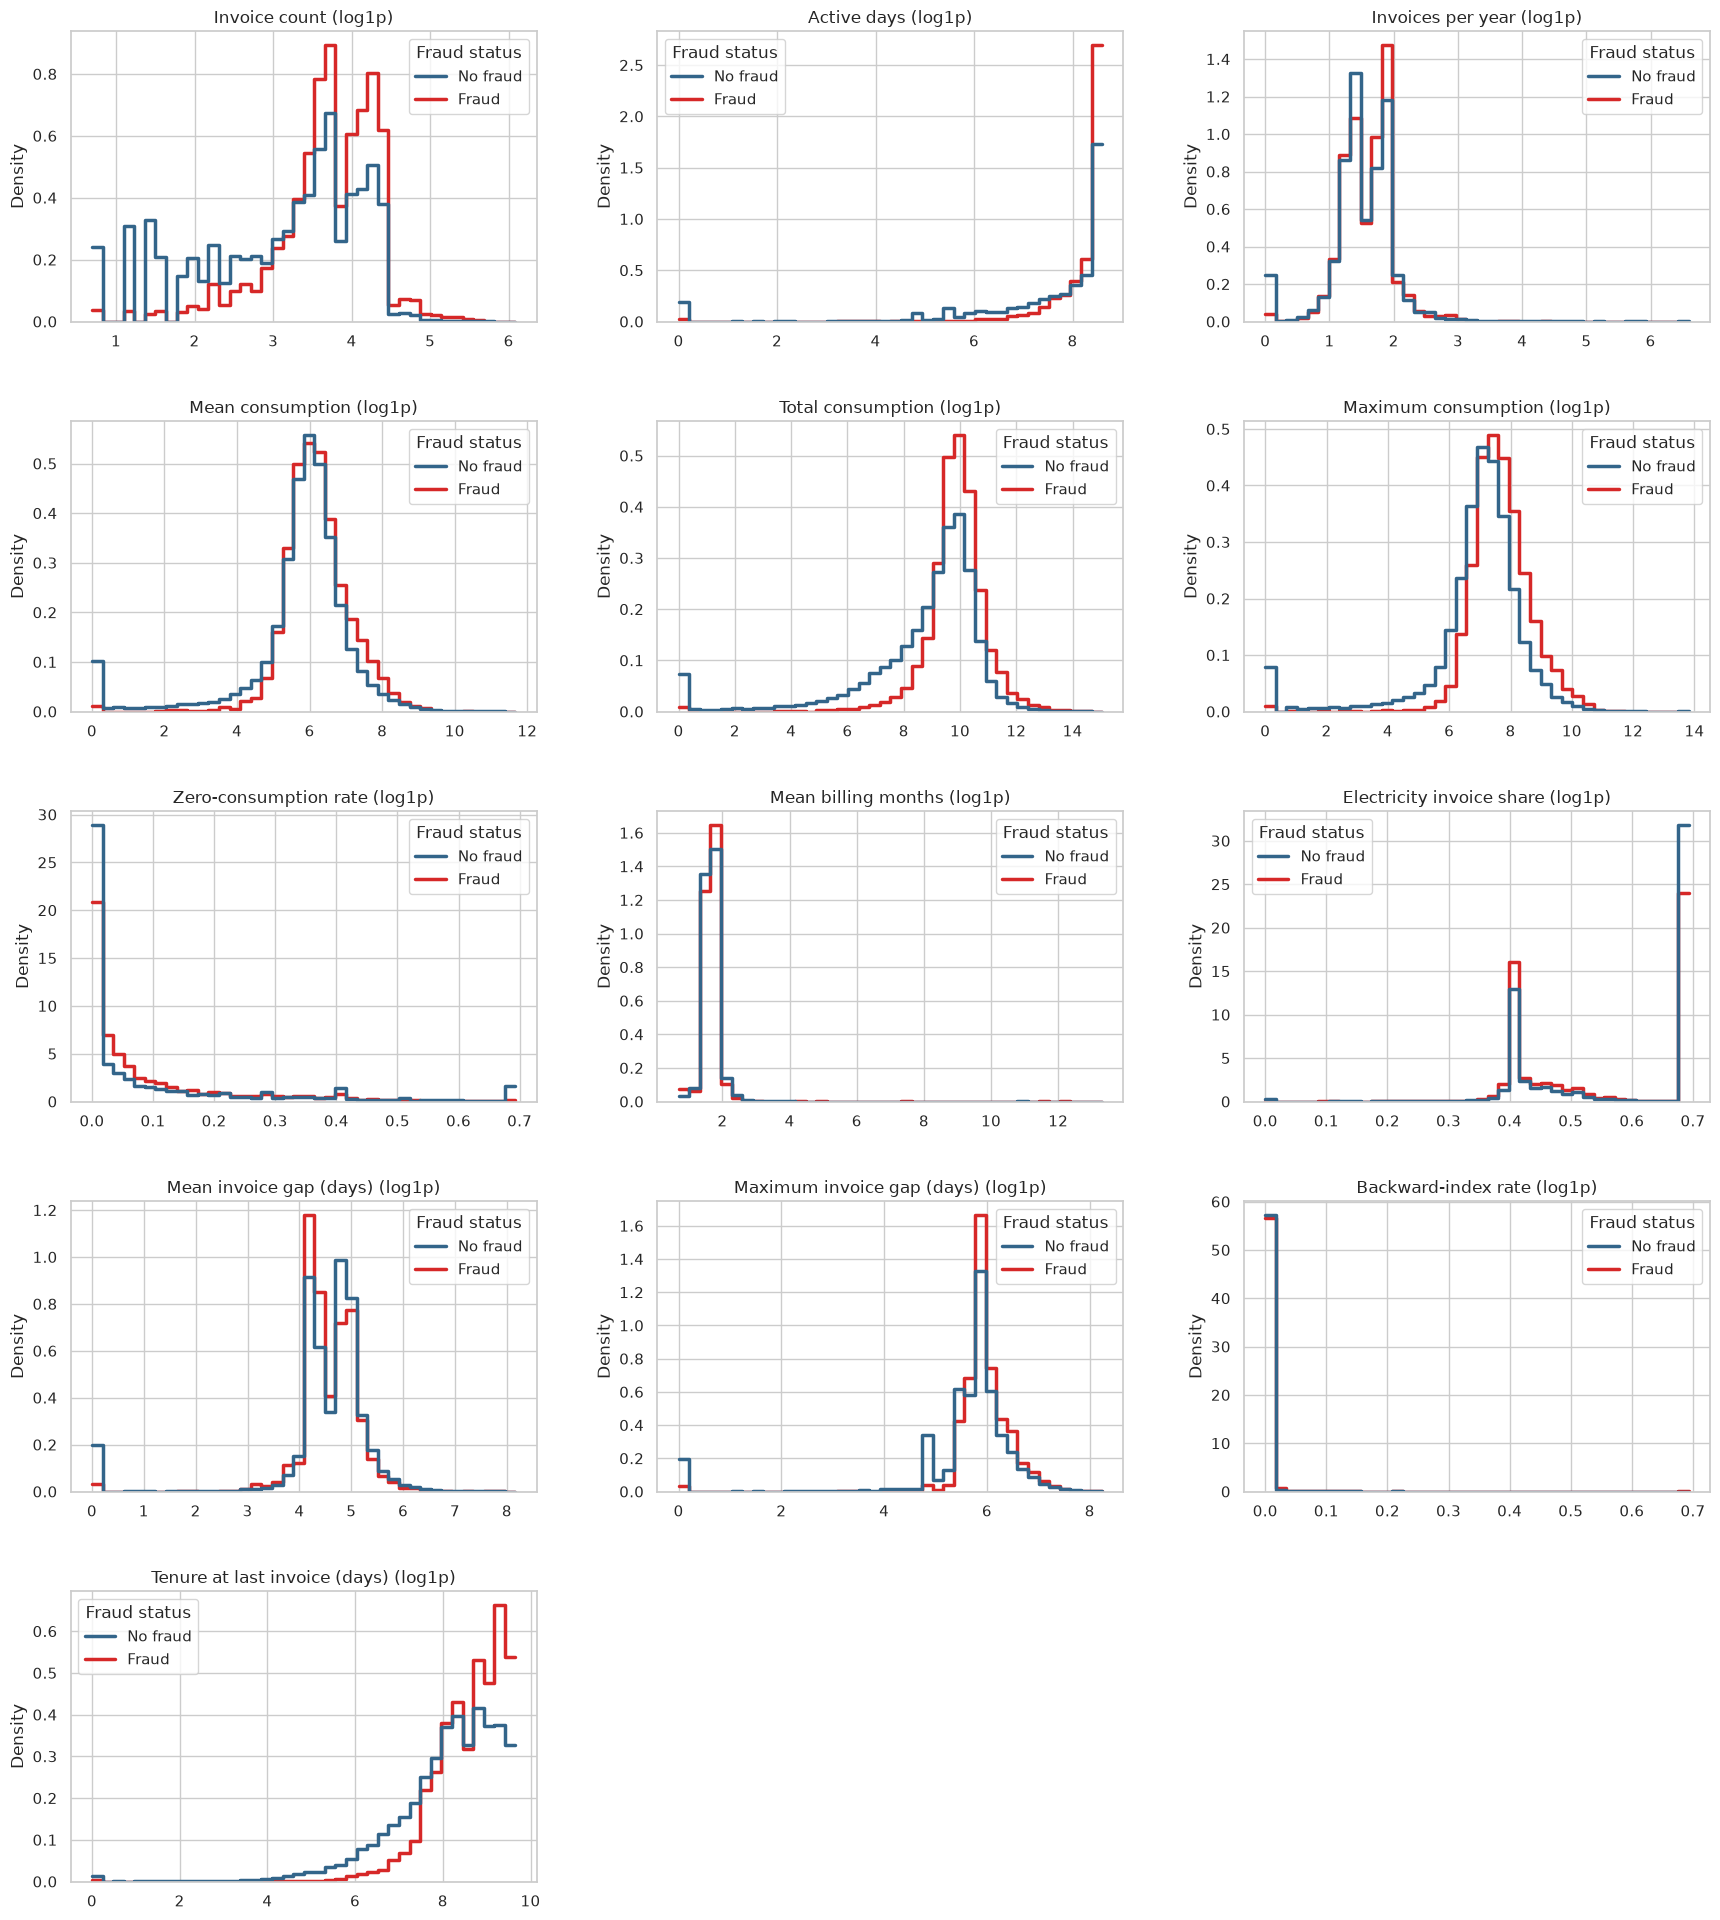

target                                                  0             1
invoice_count                        median          29.0          41.0
                                     mean       32.234298     46.670896
active_days                          median        3283.0        4727.0
                                     mean     2965.868222   3993.599524
invoice_frequency_per_year           median      3.464431      4.127984
                                     mean        4.294846      4.340084
mean_consumption                     median    392.860465    465.836194
                                     mean      641.413785    767.105857
total_consumption_sum                median       11491.0       19905.0
                                     mean    18852.512402  32428.977267
total_consumption_max                median        1280.0        2016.0
                                     mean      2259.92516    3557.49696
zero_consumption_rate                median      0.017241      0.038462
                                     mean         0.12825      0.106759
mean_months                          median           4.2      4.207222
                                     mean       32.426174     42.963713
elec_share                           median           1.0      0.634921
                                     mean        0.790915      0.734382
mean_invoice_gap_days                median    114.928571     89.761983
                                     mean      117.955161    110.253682
max_invoice_gap_days                 median         349.0         366.0
                                     mean      374.043134    438.408935
backwards_index_rate                 median           0.0           0.0
                                     mean        0.000523      0.001074
customer_tenure_days_at_last_invoice median        4008.0        6285.0
                                     mean      5138.86239   6869.594898

In [139]:
eda_features = [
    "invoice_count",
    "active_days",
    "invoice_frequency_per_year",
    "mean_consumption",
    "total_consumption_sum",
    "total_consumption_max",
    "zero_consumption_rate",
    "mean_months",
    "elec_share",
    "mean_invoice_gap_days",
    "max_invoice_gap_days",
    "backwards_index_rate",
    "customer_tenure_days_at_last_invoice",
]

# Labels keep charts readable without changing the real column names in client_features.
feature_labels = {
    "invoice_count": "Invoice count",
    "active_days": "Active days",
    "invoice_frequency_per_year": "Invoices per year",
    "mean_consumption": "Mean consumption",
    "total_consumption_sum": "Total consumption",
    "total_consumption_max": "Maximum consumption",
    "zero_consumption_rate": "Zero-consumption rate",
    "mean_months": "Mean billing months",
    "elec_share": "Electricity invoice share",
    "mean_invoice_gap_days": "Mean invoice gap (days)",
    "max_invoice_gap_days": "Maximum invoice gap (days)",
    "backwards_index_rate": "Backward-index rate",
    "customer_tenure_days_at_last_invoice": "Tenure at last invoice (days)",
}

# Plot distributions separately for each class. Density lets us compare shapes despite class imbalance.
plot_data = client_features[eda_features + ["target"]].copy()
plot_data["Fraud status"] = plot_data["target"].map({0: "No fraud", 1: "Fraud"})
class_palette = {"No fraud": "#33658A", "Fraud": "#D62828"}
fig, ax = plt.subplots(5, 3, figsize=(18, 20))
for count, feature in enumerate(eda_features):
    plot_frame = pd.DataFrame({
        "value": np.log1p(plot_data[feature].clip(lower=0)),
        "Fraud status": plot_data["Fraud status"],
    })
    sns.histplot(
        data=plot_frame,
        x="value",
        hue="Fraud status",
        hue_order=["No fraud", "Fraud"],
        palette=class_palette,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=40,
        linewidth=2.5,
        ax=ax[int(count / 3)][count % 3],
    )
    ax[int(count / 3)][count % 3].set(title=f"{feature_labels[feature]} (log1p)", xlabel="")
for empty_ax in ax.flat[len(eda_features):]:
    empty_ax.set_visible(False)
fig.tight_layout(pad=3)
plt.show()

summary_by_target = client_features.groupby("target")[eda_features].agg(["median", "mean"])
display(summary_by_target.T)

### Look at relationships between features

The pairplot uses a small random sample of training clients because drawing all clients would be slow and unreadable. Blue points are non-fraud; red points are fraud and deliberately less transparent so they stay visible. It helps us see whether the two groups overlap.

The heatmap and tables below make the next decision explicit. First, we rank each feature by its simple linear relationship with the fraud target. Then, we list feature pairs that are strongly correlated with each other. 

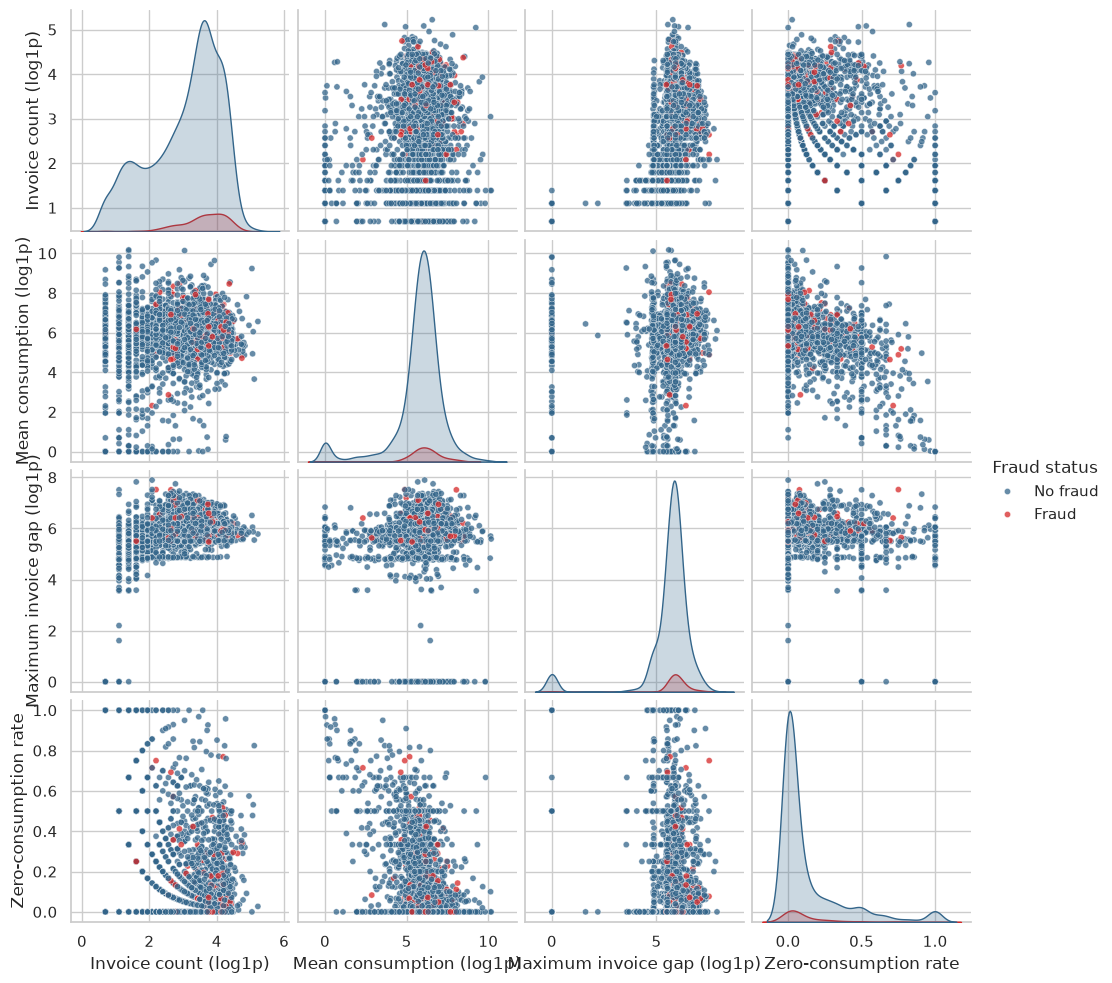

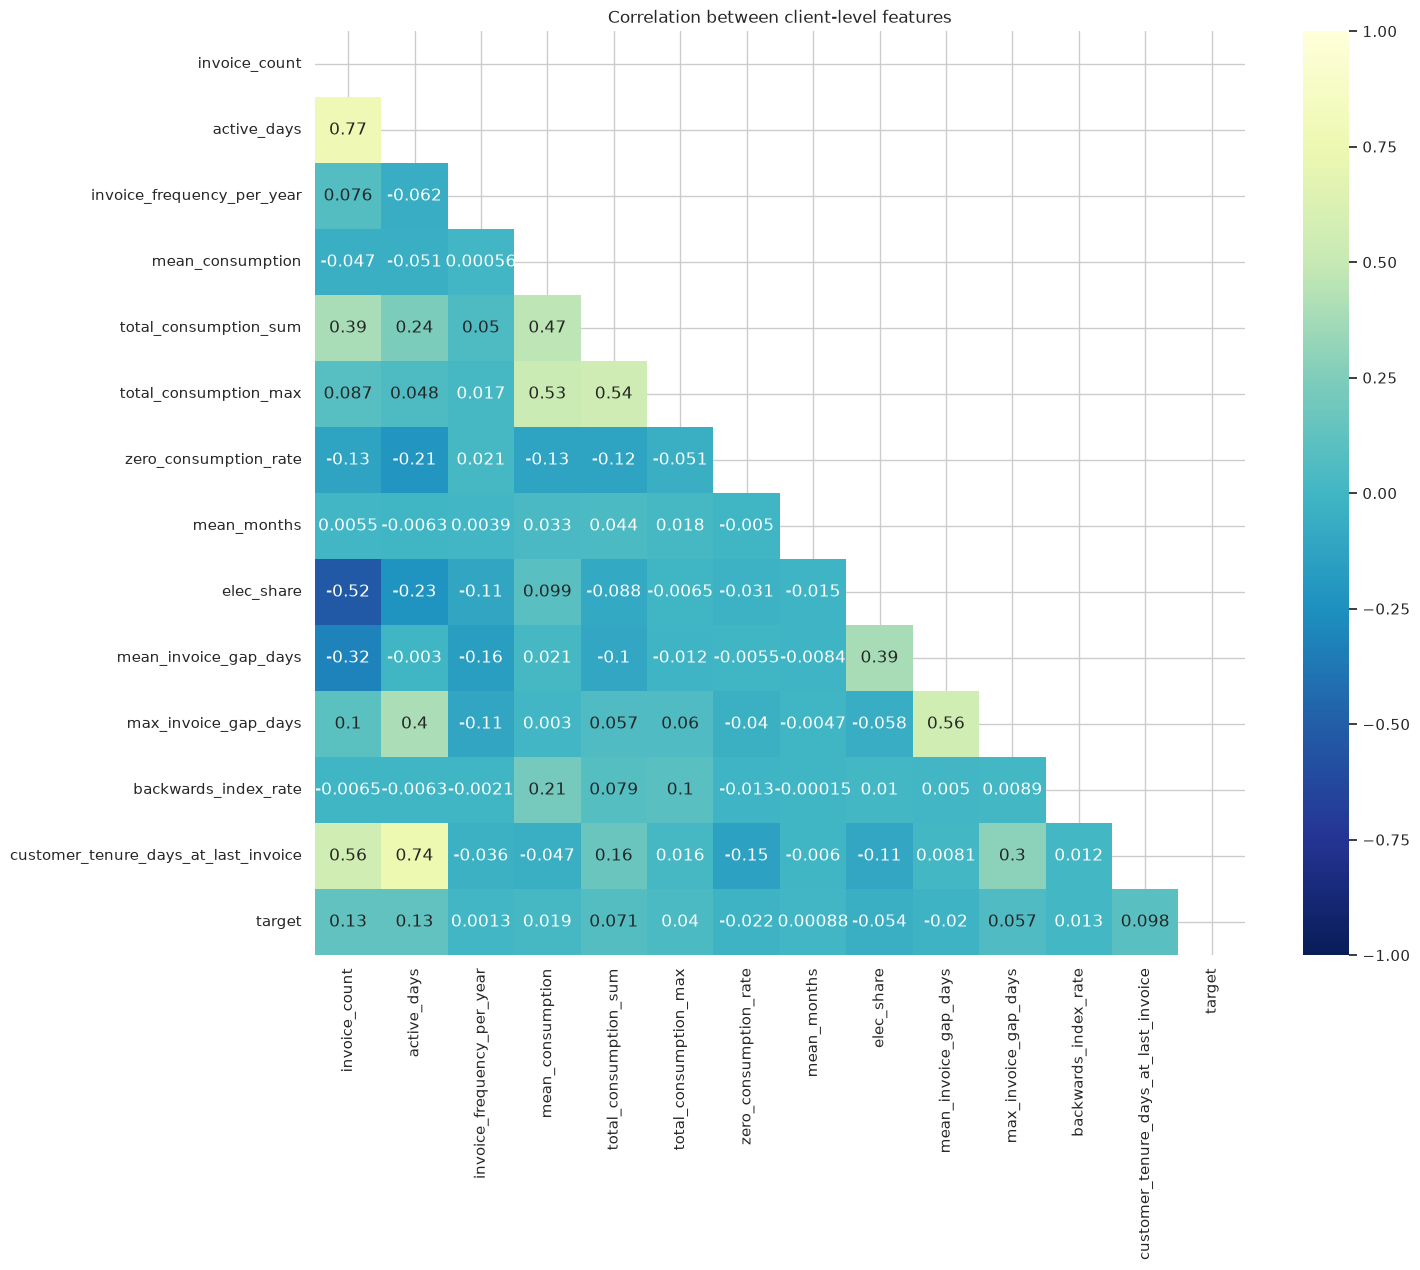

,correlation_with_fraud,absolute_correlation
Active days,0.127691,0.127691
Invoice count,0.127044,0.127044
Tenure at last invoice (days),0.097653,0.097653
Total consumption,0.071110,0.071110
Maximum invoice gap (days),0.057497,0.057497
Electricity invoice share,-0.053799,0.053799
Maximum consumption,0.039959,0.039959
Zero-consumption rate,-0.021919,0.021919
Mean invoice gap (days),-0.019885,0.019885
Mean consumption,0.019481,0.019481


,feature_1,feature_2,correlation,recommended next step
1,Invoice count,Active days,0.768666,Keep both for now; compare later in modelling
25,Active days,Tenure at last invoice (days),0.743318,Keep both for now; compare later in modelling


In [140]:
# Pairplot: use a sample so the plot stays readable and fast
pairplot_columns = ["invoice_count", "mean_consumption", "max_invoice_gap_days", "zero_consumption_rate", "target"]
pairplot_data = client_features[pairplot_columns].sample(n=min(3_000, len(client_features)), random_state=RSEED)
pairplot_data["invoice_count"] = np.log1p(pairplot_data["invoice_count"])
pairplot_data["mean_consumption"] = np.log1p(pairplot_data["mean_consumption"].clip(lower=0))
pairplot_data["max_invoice_gap_days"] = np.log1p(pairplot_data["max_invoice_gap_days"])
pairplot_data["Fraud status"] = pairplot_data["target"].map({0: "No fraud", 1: "Fraud"})
pairplot_data = pairplot_data.rename(columns={
    "invoice_count": "Invoice count (log1p)",
    "mean_consumption": "Mean consumption (log1p)",
    "max_invoice_gap_days": "Maximum invoice gap (log1p)",
    "zero_consumption_rate": "Zero-consumption rate",
})
sns.pairplot(
    pairplot_data.drop(columns="target"),
    hue="Fraud status",
    hue_order=["No fraud", "Fraud"],
    palette=class_palette,
    plot_kws={"s": 20, "alpha": 0.75},
)
plt.show()

# Correlation between numeric client-level features
corr = client_features[eda_features + ["target"]].corr(numeric_only=True)
plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap="YlGnBu_r", mask=mask, vmax=1, vmin=-1)
plt.title("Correlation between client-level features")
plt.show()

# Which individual numeric features have the strongest simple relationship with the fraud target?
# This is an EDA clue, not proof that a feature will be useful on its own.
target_correlations = (
    corr["target"]
    .drop("target")
    .rename("correlation_with_fraud")
    .to_frame()
    .assign(absolute_correlation=lambda table: table["correlation_with_fraud"].abs())
    .sort_values("absolute_correlation", ascending=False)
)
target_correlations.index = target_correlations.index.map(feature_labels)
display(target_correlations)

# Which pairs carry very similar information? Show only correlations of 0.70 or more.
feature_pair_correlations = (
    corr.drop(index="target", columns="target")
    .where(np.triu(np.ones((len(eda_features), len(eda_features)), dtype=bool), k=1))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
feature_pair_correlations["absolute_correlation"] = feature_pair_correlations["correlation"].abs()
strong_feature_pairs = feature_pair_correlations.loc[
    feature_pair_correlations["absolute_correlation"].ge(0.70)
].copy()
strong_feature_pairs["recommended next step"] = np.where(
    strong_feature_pairs["absolute_correlation"].ge(0.90),
    "Test keeping only one in logistic regression",
    "Keep both for now; compare later in modelling",
)
strong_feature_pairs["feature_1"] = strong_feature_pairs["feature_1"].map(feature_labels)
strong_feature_pairs["feature_2"] = strong_feature_pairs["feature_2"].map(feature_labels)
strong_feature_pairs = strong_feature_pairs.sort_values("absolute_correlation", ascending=False)
display(strong_feature_pairs[["feature_1", "feature_2", "correlation", "recommended next step"]])

### What these correlations tell us

- No single numeric feature has a strong linear relationship with fraud. The largest target correlations are **active days (0.128)** and **invoice count (0.127)**. We should not expect one simple numeric rule to identify fraud.
- **Invoice count and active days correlate at 0.769.** They both describe the amount of client history, but in different ways: number of invoices and time covered. We keep both in the 15-input baseline.
- **Active days and tenure at last invoice correlate at 0.743.** We exclude tenure because it depends on unreliable creation dates, and use active days instead.
- No pair exceeds 0.90. The correlation table therefore gives no reason to drop a feature automatically.
- Backward-index rate, mean billing months, and invoices per year have almost **no *linear* correlation with fraud**. Only `backwards_index_rate` is in the 15-input baseline. `mean_billing_months` and `invoice_frequency_per_year` are postponed for later work.

### Fraud rate by client category, region, and district

The correlations above only look at numeric invoice-history features. `client_catg`, `region`, and `disrict` are categorical, so we check them separately: for each category, what share of clients are labelled fraud? We only trust categories with at least 50 clients, since smaller groups give noisy rates.

In [141]:
def fraud_rate_by_group(frame, column, minimum_clients=50):
    result = frame.groupby(column, dropna=False)["target"].agg(clients="size", fraud_rate="mean")
    return result.query("clients >= @minimum_clients").sort_values("fraud_rate", ascending=False)

display(fraud_rate_by_group(client_features, "client_catg"))
display(fraud_rate_by_group(client_features, "region").head(20))
display(fraud_rate_by_group(client_features, "disrict"))

,clients,fraud_rate
client_catg,,
51,1678,0.168653
11,131494,0.054687
12,2321,0.039638


,clients,fraud_rate
region,,
103,8964,0.102967
372,644,0.100932
311,12406,0.080445
106,706,0.075071
308,841,0.072533
371,2065,0.071671
313,2076,0.070809
379,583,0.066895
304,3828,0.066876


,clients,fraud_rate
disrict,,
69,34231,0.071485
63,28987,0.065236
62,40353,0.051619
60,31922,0.035869


`client_catg == 51` stands out clearly: a fraud rate around **17%**, roughly 3x the overall base rate, on a large enough group of clients to trust (not noise). `region` and `disrict` fraud rates vary by roughly 2-3x across categories too. 

**Worth encoding all three as categorical features, and worth checking model performance per-category later rather than trusting one global score.**

### Check the target and remaining data-quality questions

First, this cell shows the fraud/non-fraud balance in `client_features`. Then it compares fraud rates for clients with short and long invoice histories. Finally, it collects the data-quality checks in one table: duplicates, missing values, clients without invoices, and unusual date/index values. These results tell us what needs attention before modelling.

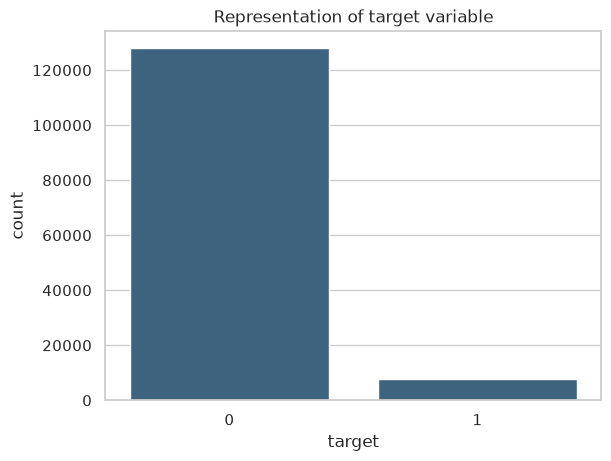

target,not_fraud,fraud
invoice_count_group,,
"(0.999, 7.0]",0.990568,0.009432
"(7.0, 22.0]",0.963815,0.036185
"(22.0, 36.0]",0.932695,0.067305
"(36.0, 57.0]",0.923443,0.076557
"(57.0, 439.0]",0.908524,0.091476


,count
duplicate_client_rows,0
duplicate_client_ids,0
missing_client_cells,0
missing_invoice_cells,0
duplicate_invoice_row_hash_matches,11
clients_without_invoices,0
invoice_clients_without_client_row,0
clients_with_backwards_index,1816
creation_after_first_invoice,8748
negative_customer_tenure,397


,creation_date,first_invoice,last_invoice
min,1977-02-05,1977-06-09,1977-06-16
max,2019-09-10,2019-12-07,2019-12-07


In [142]:
# Representation of the target variable in all labelled client data
sns.countplot(x=client_features["target"], color="#33658A").set_title("Representation of target variable")
plt.show()

# Check whether the fraud rate changes with the amount of invoice history
client_features["invoice_count_group"] = pd.qcut(client_features["invoice_count"], q=5, duplicates="drop")
history_table = pd.crosstab(
    client_features["invoice_count_group"],
    client_features["target"],
    normalize="index",
).rename(columns={0: "not_fraud", 1: "fraud"})
display(history_table)

# Plot the fraud share in each history group so the observation-window pattern is visible.
history_table["fraud"].plot(kind="bar", color="#D62728", figsize=(9, 4), title="Fraud rate by invoice-history group")
plt.ylabel("Fraud rate")
plt.xlabel("Invoice-count group")
plt.ylim(0, max(history_table["fraud"].max() * 1.15, 0.1))
plt.tight_layout()
plt.show()

quality_checks = pd.Series({
    "duplicate_client_rows": int(client.duplicated().sum()),
    "duplicate_client_ids": int(client["client_id"].duplicated().sum()),
    "missing_client_cells": int(client.isna().sum().sum()),
    "missing_invoice_cells": int(invoice_audit["missing_by_column"].sum()),
    "duplicate_invoice_row_hash_matches": invoice_audit["duplicate_row_hash_matches"],
    "clients_without_invoices": len(clients_without_invoices),
    "invoice_clients_without_client_row": len(unknown_invoice_clients),
    "clients_with_backwards_index": int(client_features["backwards_index_count"].gt(0).sum()),
    "creation_after_first_invoice": int(client_features["creation_date"].gt(client_features["first_invoice"]).sum()),
    "negative_customer_tenure": int(client_features["customer_tenure_days_at_last_invoice"].lt(0).sum()),
}, name="count")
display(quality_checks.to_frame())

display(client_features[["creation_date", "first_invoice", "last_invoice"]].agg(["min", "max"]))

In [143]:
# Name the pattern explicitly and quantify it, since it's the single biggest modelling risk here.
observation_window_ratio = history_table["fraud"].iloc[-1] / history_table["fraud"].iloc[0]
print(
    f"Observation-window bias: fraud rate is {observation_window_ratio:.1f}x higher in the "
    f"longest-history quintile ({history_table['fraud'].iloc[-1]:.1%}) than the shortest-history "
    f"quintile ({history_table['fraud'].iloc[0]:.1%}). This is a strong signal that invoice-history "
    "length itself is confounded with the label and needs explicit handling before modelling, not "
    "just treated as a normal feature."
)

Observation-window bias: fraud rate is 9.7x higher in the longest-history quintile (9.1%) than the shortest-history quintile (0.9%). This is a strong signal that invoice-history length itself is confounded with the label and needs explicit handling before modelling, not just treated as a normal feature.


### Inspect the records that need a closer look

The checklist above counts potential data problems. This next cell shows examples, but does **not** delete or correct anything. 
- A duplicate hash is only a signal that two invoice rows have the same values; we inspect it before deciding whether it is a real duplicate.
- A backward index is a negative change in a meter reading. The date examples help us decide whether account-creation dates are reliable enough to use as a model feature.

In [144]:
# First, summarise what each unusual pattern means and what we will decide later.
unusual_records_summary = pd.DataFrame([
    {
        "check": "Duplicate-looking invoice rows",
        "count": invoice_audit["duplicate_row_hash_matches"],
        "meaning": "Two or more invoice rows have the same values in every checked column.",
        "next step": "Inspect the matching rows; only remove them if they are true duplicates.",
    },
    {
        "check": "Clients with a backward meter index",
        "count": int(client_features["backwards_index_count"].gt(0).sum()),
        "meaning": "At least one invoice has a meter index lower than the previous reading.",
        "next step": "Keep it as a possible signal; investigate whether it is a reset or correction.",
    },
    {
        "check": "Creation date after first invoice",
        "count": int(client_features["creation_date"].gt(client_features["first_invoice"]).sum()),
        "meaning": "The recorded account-creation date is later than the first invoice date.",
        "next step": "Do not assume creation_date is a reliable start-of-service date.",
    },
    {
        "check": "Negative customer tenure",
        "count": int(client_features["customer_tenure_days_at_last_invoice"].lt(0).sum()),
        "meaning": "The last invoice is dated before the recorded account-creation date.",
        "next step": "Do not use negative tenure as-is; handle it explicitly during modelling.",
    },
])
display(unusual_records_summary)

# Read only the rows whose hashes matched, so we can inspect the possible invoice duplicates.
duplicate_hashes = set(invoice_audit["duplicate_row_hashes"])
duplicate_invoice_examples = []
if duplicate_hashes:
    invoice_file = pq.ParquetFile(PARQUET_DIR / "invoice_train.parquet")
    for batch in invoice_file.iter_batches(batch_size=CHUNK_SIZE):
        invoice_chunk = batch.to_pandas()
        # Apply the same data types and optional date filter used in aggregate_invoices.
        invoice_chunk["client_id"] = invoice_chunk["client_id"].astype("string")
        invoice_chunk["counter_statue"] = invoice_chunk["counter_statue"].astype("string")
        invoice_chunk["invoice_date"] = pd.to_datetime(invoice_chunk["invoice_date"], errors="raise")
        if AS_OF_DATE is not None:
            invoice_chunk = invoice_chunk.loc[invoice_chunk["invoice_date"].le(pd.Timestamp(AS_OF_DATE))].copy()
        row_hash = pd.util.hash_pandas_object(invoice_chunk, index=False)
        matches = invoice_chunk.loc[row_hash.isin(duplicate_hashes)]
        if not matches.empty:
            duplicate_invoice_examples.append(matches)

if duplicate_invoice_examples:
    duplicate_invoice_examples = pd.concat(duplicate_invoice_examples, ignore_index=True)
    print("Potential duplicate invoice rows (all matching rows are shown):")
    display(duplicate_invoice_examples.sort_values(["client_id", "invoice_date"]))
else:
    print("No matching invoice rows were found to display.")

# Show the clients with the most backward readings, then a small sample of each date issue.
backwards_index_examples = (
    client_features.loc[client_features["backwards_index_count"].gt(0), [
        "client_id", "target", "backwards_index_count", "index_delta_min", "invoice_count"
    ]]
    .sort_values(["backwards_index_count", "index_delta_min"], ascending=[False, True])
    .head(10)
)
print("Examples: clients with backward meter indices")
display(backwards_index_examples)

creation_after_first_invoice_examples = (
    client_features.loc[client_features["creation_date"].gt(client_features["first_invoice"]), [
        "client_id", "target", "creation_date", "first_invoice", "last_invoice",
        "customer_tenure_days_at_last_invoice"
    ]]
    .sort_values(["creation_date", "first_invoice"])
    .head(10)
)
print("Examples: account creation date after first invoice")
display(creation_after_first_invoice_examples)

negative_tenure_examples = (
    client_features.loc[client_features["customer_tenure_days_at_last_invoice"].lt(0), [
        "client_id", "target", "creation_date", "last_invoice",
        "customer_tenure_days_at_last_invoice"
    ]]
    .sort_values("customer_tenure_days_at_last_invoice")
    .head(10)
)
print("Examples: clients with negative customer tenure")
display(negative_tenure_examples)

,check,count,meaning,next step
0,Duplicate-looking invoice rows,11,Two or more invoice rows have the same values ...,Inspect the matching rows; only remove them if...
1,Clients with a backward meter index,1816,At least one invoice has a meter index lower t...,Keep it as a possible signal; investigate whet...
2,Creation date after first invoice,8748,The recorded account-creation date is later th...,Do not assume creation_date is a reliable star...
3,Negative customer tenure,397,The last invoice is dated before the recorded ...,Do not use negative tenure as-is; handle it ex...


Potential duplicate invoice rows (all matching rows are shown):


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
1,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
2,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
3,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
4,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
5,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
6,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
7,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
8,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC
9,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC


Examples: clients with backward meter indices


,client_id,target,backwards_index_count,index_delta_min,invoice_count
44468,train_Client_18075,0,8,-9066,37
35861,train_Client_132271,1,7,-98432,122
58312,train_Client_30534,0,6,-97607,168
73888,train_Client_44553,0,6,-97145,236
81802,train_Client_51676,1,6,-96950,223
22730,train_Client_120453,0,5,-99566,76
108926,train_Client_76088,0,5,-98822,248
55184,train_Client_2772,0,5,-98215,30
25899,train_Client_123305,0,5,-97087,105
88378,train_Client_57595,1,5,-96506,135


Examples: account creation date after first invoice


,client_id,target,creation_date,first_invoice,last_invoice,customer_tenure_days_at_last_invoice
127022,train_Client_92374,0,1977-09-07,1977-08-11,1977-08-11,-27
54062,train_Client_2671,0,1978-02-21,1978-02-10,1978-04-13,51
66235,train_Client_37666,0,1978-05-11,1978-02-10,1979-03-28,321
31115,train_Client_12800,0,1978-07-04,1978-05-10,1978-07-27,23
118925,train_Client_85087,0,1978-07-04,1978-05-10,1978-07-27,23
34306,train_Client_130872,0,1978-07-29,1978-07-12,1979-07-06,342
20820,train_Client_118735,0,1979-04-16,1979-03-12,1979-09-28,165
64073,train_Client_3572,0,1980-07-21,1980-03-11,1981-02-01,195
59965,train_Client_32021,0,1980-08-23,1980-03-10,1981-05-02,252
40588,train_Client_14583,0,1981-05-09,1981-03-06,1981-03-06,-64


Examples: clients with negative customer tenure


,client_id,target,creation_date,last_invoice,customer_tenure_days_at_last_invoice
81524,train_Client_51425,0,2003-11-27,2003-01-12,-319
128948,train_Client_94107,0,2007-10-29,2007-01-11,-291
39242,train_Client_135314,0,2005-10-28,2005-01-12,-289
88141,train_Client_57381,0,2008-11-24,2008-02-12,-286
110447,train_Client_77457,0,2011-10-22,2011-01-12,-283
121915,train_Client_87779,0,2016-11-17,2016-02-12,-279
104172,train_Client_71809,0,2016-11-17,2016-02-12,-279
19632,train_Client_117666,0,2016-11-17,2016-02-12,-279
42634,train_Client_16424,0,2008-11-15,2008-02-12,-277
66388,train_Client_37803,0,2010-11-12,2010-02-12,-273


## Results

### What we learned

- The data contains **135,493 labelled clients** and **4,476,749 invoice rows**. Each client has invoice data, and every invoice belongs to a client in the client table.
- There are **no missing values** in either source table. This means missing-value imputation is not the first issue to solve for this baseline.
- Fraud is imbalanced: **7,566 clients (5.58%)** are labelled as fraud. A model that predicts `not fraud` for everyone would be about 94% accurate but would find no fraud, so accuracy should not be our main metric.
- Fraud clients tend to have more invoice history. The median fraud client has **41 invoices** compared with **29** for a non-fraud client, and **4,727 active days** compared with **3,283**. This is a useful association, but it may partly reflect how long a client has been observed, so we need to check it carefully.
- The strongest simple pattern is invoice count: the fraud rate rises from **0.94%** for clients with 1–7 invoices to **9.15%** for clients with 58–439 invoices — a 9.7x range (see the "observation-window bias" note below Step 3's history table). Invoice count should be tested in the first model, but we must check whether it dominates the ranking.
- Consumption also differs. Median mean consumption is **466** for fraud clients and **393** for non-fraud clients; median maximum consumption is **2,016** versus **1,280**. These are candidate associations, but the distributions are right-skewed, so `log1p` is used only to make the EDA visualisation readable.
- The invoice features are related to each other: invoice count, active days, total consumption, and invoice frequency describe overlapping parts of a client’s history. For a simple linear model, we should avoid adding every highly related feature without checking the result.
- `client_catg`, `region`, and `disrict` are also worth using: `client_catg == 51` has a fraud rate around 3x the base rate on a large enough group to trust, and `region`/`disrict` fraud rates vary by roughly 2-3x across categories.

### Data-quality decisions

- There are **11 duplicate-looking invoice row hashes**. This is tiny compared with 4.5 million invoices. We will inspect the displayed rows before deciding whether they are true duplicates; we will not remove them automatically.
- **1,816 clients** have at least one backward meter index. This could be a correction or meter reset, but it could also be useful behaviour. Keep `backwards_index_rate` in the baseline. `backwards_index_count` is postponed because the rate is fairer for clients with different numbers of invoices.
- **8,748 clients** have a creation date later than their first invoice and **397 clients** have negative tenure at their last invoice. Therefore, `creation_date` is not always a trustworthy start-of-service date. Do not use raw `creation_date` or date-derived tenure as baseline inputs.

### Next steps for the baseline

1. Use the complete df_training table created at the end of this notebook. The modelling notebook owns the client-level evaluation split.
2. Start with a DummyClassifier, then a regularised logistic regression using the client features already created. This gives us a simple reference that is easy to explain. The modelling notebook should create its evaluation split before fitting its model pipeline. This EDA does not create a holdout.
3. Report **average precision** as the main ranking metric because fraud is rare. Also report recall, precision, and a confusion matrix at a business-chosen threshold or review capacity.
4. Use `backwards_index_rate`, but document that a backward index can mean a correction or meter reset—not necessarily fraud.
5. Add `client_catg`, `region`, and `disrict` as categorical inputs. One-hot encode their category codes rather than treating them as numeric values; no separate `client_catg == 51` flag is needed.
6. Use the modelling notebook's held-out predictions for false-positive and false-negative error analysis; the separate Kaggle test data is unlabelled and cannot provide local metrics.

## Step 4 — Data quality: what we keep, exclude, and investigate

The earlier checklist and examples tell us *what* looks unusual. Here we decide whether each issue should be dropped, kept, or changed before modelling. The fraud-rate comparison uses all labelled client data; the model split is still created later.

For each client-level issue, compare the fraud rate for clients with the issue to clients without it. A difference does not prove fraud, but it tells us whether the issue could contain useful information.

In [145]:
# Create clear yes/no flags in all labelled client data for this comparison.
decision_data = client_features.assign(
    has_backward_index=client_features["backwards_index_count"].gt(0),
    creation_after_first_invoice=client_features["creation_date"].gt(client_features["first_invoice"]),
    has_negative_tenure=client_features["customer_tenure_days_at_last_invoice"].lt(0),
)

# For each issue, show how many clients it affects and whether its fraud rate differs.
issue_labels = {
    "has_backward_index": "At least one backward meter index",
    "creation_after_first_invoice": "Creation date after first invoice",
    "has_negative_tenure": "Negative customer tenure",
}
fraud_rate_tables = []
for issue, label in issue_labels.items():
    comparison = (
        decision_data.groupby(issue)["target"]
        .agg(clients="size", fraud_cases="sum", fraud_rate="mean")
        .reset_index()
        .rename(columns={issue: "has_issue"})
    )
    comparison.insert(0, "issue", label)
    comparison["group"] = comparison["has_issue"].map({False: "No", True: "Yes"})
    fraud_rate_tables.append(comparison[["issue", "group", "clients", "fraud_cases", "fraud_rate"]])

issue_fraud_rates = pd.concat(fraud_rate_tables, ignore_index=True)
issue_fraud_rates["fraud_rate"] = issue_fraud_rates["fraud_rate"].map(lambda rate: f"{rate:.2%}")
display(issue_fraud_rates)

# The duplicate check is invoice-level, not client-level. Its scale tells us whether it can materially change the aggregates.
duplicate_impact = pd.DataFrame({
    "duplicate-looking invoice rows": [invoice_audit["duplicate_row_hash_matches"]],
    "all invoice rows": [invoice_audit["invoice_rows"]],
})
duplicate_impact["share of invoice rows"] = (
    duplicate_impact["duplicate-looking invoice rows"] / duplicate_impact["all invoice rows"]
).map(lambda share: f"{share:.5%}")
display(duplicate_impact)

# Final decision table for the baseline. These actions preserve the raw data and make the modelling choices explicit.
model_data_quality_decisions = pd.DataFrame([
    {
        "issue": "Duplicate-looking invoice rows",
        "decision": "Keep for now",
        "why": "Only 11 matches in more than 4.4 million invoice rows; without a unique invoice ID we cannot prove they are accidental duplicates.",
        "model action": "Do not delete automatically. Revisit only if inspection confirms true duplicates.",
    },
    {
        "issue": "Backward meter index",
        "decision": "Keep and model",
        "why": "It may represent a correction or reset, but it is also potentially useful behaviour. The comparison above shows its fraud rate.",
        "model action": "Keep backwards_index_count and backwards_index_rate; do not drop the affected invoices.",
    },
    {
        "issue": "Creation date after first invoice",
        "decision": "Do not use raw creation date",
        "why": "The date cannot consistently represent the start of a customer's service history.",
        "model action": "Do not model creation_date directly. Keep a validity flag only if it improves the later model.",
    },
    {
        "issue": "Negative customer tenure",
        "decision": "Manipulate before modelling",
        "why": "Negative tenure is not meaningful as duration, but the invalid-date flag could be informative.",
        "model action": "Replace negative tenure with missing values and add a negative-tenure indicator inside the model pipeline.",
    },
])
display(model_data_quality_decisions)

,issue,group,clients,fraud_cases,fraud_rate
0,At least one backward meter index,No,133677,7360,5.51%
1,At least one backward meter index,Yes,1816,206,11.34%
2,Creation date after first invoice,No,126745,7102,5.60%
3,Creation date after first invoice,Yes,8748,464,5.30%
4,Negative customer tenure,No,135096,7560,5.60%
5,Negative customer tenure,Yes,397,6,1.51%


,duplicate-looking invoice rows,all invoice rows,share of invoice rows
0,11,4476749,0.00025%


,issue,decision,why,model action
0,Duplicate-looking invoice rows,Keep for now,Only 11 matches in more than 4.4 million invoi...,Do not delete automatically. Revisit only if i...
1,Backward meter index,Keep and model,"It may represent a correction or reset, but it...",Keep backwards_index_count and backwards_index...
2,Creation date after first invoice,Do not use raw creation date,The date cannot consistently represent the sta...,Do not model creation_date directly. Keep a va...
3,Negative customer tenure,Manipulate before modelling,"Negative tenure is not meaningful as duration,...",Replace negative tenure with missing values an...


### Step 4 result

We will **not drop raw invoice records** for the baseline. The duplicate-looking rows are too few to materially affect the data and need confirmation first. We will **keep backward-index behaviour** as an aggregated feature, not as a reason to delete records. We will **not use raw `creation_date` or date-derived tenure** as predictors because the recorded creation date is not reliable for every client.

The data-quality checks tell us what to keep, not what to delete. We keep the raw records and use only the reliable, client-level summaries selected at the end of this notebook.

## Step 5 — Create features from meter-reading patterns

Each invoice contains a meter reading. For each meter identifier (`client_id` + `counter_number`), we order the invoice-dated readings and compare the current `new_index` with the previous one. This creates features about the number of recorded meters, backward reading changes, and the size of reading changes over time. The data does not independently confirm that each identifier always represents one physical meter.

We also convert the reading change to an approximate monthly value by dividing by the days between readings and multiplying by 30.44. This makes changes more comparable when clients have different invoice intervals. Same-day readings are excluded from this sequence calculation because their order is unknown.

In [146]:
def aggregate_meter_submissions(path, chunk_size=250_000, as_of_date=None):
    """Create one set of meter-submission features per client without loading all invoices at once."""
    client_summaries = []
    closed_client_ids = set()
    carry_over = pd.DataFrame()
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None

    def summarise_complete_clients(readings):
        # These clients have all their readings in this batch, so vectorised groupby is safe and fast.
        completed_ids = set(readings["client_id"].unique())
        if completed_ids & closed_client_ids:
            raise ValueError("Invoice clients are not stored together; cannot stream meter submissions safely.")
        closed_client_ids.update(completed_ids)

        readings = readings.sort_values(["client_id", "counter_number", "invoice_date"], kind="stable")
        meter_group = readings.groupby(["client_id", "counter_number"], observed=True)
        readings["previous_new_index"] = meter_group["new_index"].shift()
        readings["previous_submission_date"] = meter_group["invoice_date"].shift()
        readings["submission_gap_days"] = (
            readings["invoice_date"] - readings["previous_submission_date"]
        ).dt.days
        readings["submission_index_delta"] = readings["new_index"] - readings["previous_new_index"]

        # A zero-day gap has no reliable submission order, so it cannot be normalised per month.
        transitions = readings.loc[readings["submission_gap_days"].gt(0)].copy()
        transitions["monthly_submission_index_delta"] = (
            transitions["submission_index_delta"] / transitions["submission_gap_days"] * 30.44
        )

        client_summary = readings.groupby("client_id", observed=True).agg(
            meter_count=("counter_number", "nunique"),
        )
        transition_summary = transitions.groupby("client_id", observed=True).agg(
            submission_transition_count=("submission_index_delta", "size"),
            mean_submission_index_delta=("submission_index_delta", "mean"),
            median_submission_index_delta=("submission_index_delta", "median"),
            mean_monthly_submission_index_delta=("monthly_submission_index_delta", "mean"),
            median_monthly_submission_index_delta=("monthly_submission_index_delta", "median"),
            median_submission_gap_days=("submission_gap_days", "median"),
            backward_submission_count=("submission_index_delta", lambda values: values.lt(0).sum()),
        )
        client_summary = client_summary.join(transition_summary, how="left").reset_index()
        client_summary[["submission_transition_count", "backward_submission_count"]] = (
            client_summary[["submission_transition_count", "backward_submission_count"]].fillna(0).astype("int64")
        )
        client_summaries.append(client_summary)

    invoice_file = pq.ParquetFile(path)
    for batch in invoice_file.iter_batches(
        batch_size=chunk_size,
        columns=["client_id", "counter_number", "invoice_date", "new_index"],
    ):
        readings_chunk = batch.to_pandas()
        readings_chunk["client_id"] = readings_chunk["client_id"].astype("string")
        readings_chunk["invoice_date"] = pd.to_datetime(readings_chunk["invoice_date"], errors="raise")
        if cutoff is not None:
            readings_chunk = readings_chunk.loc[readings_chunk["invoice_date"].le(cutoff)].copy()
        if readings_chunk.empty:
            continue

        combined = pd.concat([carry_over, readings_chunk], ignore_index=True)
        last_client_id = combined["client_id"].iloc[-1]
        complete_clients = combined.loc[combined["client_id"].ne(last_client_id)].copy()
        carry_over = combined.loc[combined["client_id"].eq(last_client_id)].copy()
        if not complete_clients.empty:
            summarise_complete_clients(complete_clients)

    if not carry_over.empty:
        summarise_complete_clients(carry_over)

    submission_features = pd.concat(client_summaries, ignore_index=True)
    submission_features["backward_submission_rate"] = np.where(
        submission_features["submission_transition_count"].gt(0),
        submission_features["backward_submission_count"] / submission_features["submission_transition_count"],
        np.nan,
    )
    return submission_features


submission_features = aggregate_meter_submissions(
    PARQUET_DIR / "invoice_train.parquet",
    chunk_size=CHUNK_SIZE,
    as_of_date=AS_OF_DATE,
)

# Add the new features safely if this cell is run more than once.
submission_feature_columns = [column for column in submission_features.columns if column != "client_id"]
client_features = client_features.drop(columns=submission_feature_columns, errors="ignore").merge(
    submission_features, on="client_id", how="left", validate="one_to_one"
)

meter_submission_features = [
    "meter_count",
    "submission_transition_count",
    "mean_monthly_submission_index_delta",
    "median_monthly_submission_index_delta",
    "median_submission_gap_days",
    "backward_submission_rate",
]
monthly_submission_summary = client_features.groupby("target")[meter_submission_features].agg(["median", "mean"])
display(monthly_submission_summary.T)

# Does a higher monthly meter increase correspond to a higher fraud rate?
monthly_delta_data = client_features.dropna(subset=["mean_monthly_submission_index_delta"])
monthly_delta_data["monthly_delta_group"] = pd.qcut(
    monthly_delta_data["mean_monthly_submission_index_delta"], q=5, duplicates="drop"
)
monthly_delta_fraud_rate = pd.crosstab(
    monthly_delta_data["monthly_delta_group"],
    monthly_delta_data["target"],
    normalize="index",
).rename(columns={0: "not_fraud", 1: "fraud"})
display(monthly_delta_fraud_rate)

# Check that the raw billing-period field supports the same conclusion rather than driving it.
billing_period_summary = client_features.groupby("target")[[
    "mean_billing_months", "four_month_bill_rate", "invoice_frequency_per_year"
]].agg(["median", "mean"])
display(billing_period_summary.T)

target                                                 0            1
meter_count                           median    2.000000     2.000000
                                      mean      1.662518     2.322363
submission_transition_count           median   27.000000    38.500000
                                      mean     30.367116    43.937880
mean_monthly_submission_index_delta   median  106.141419   129.143367
                                      mean    560.698765  1048.148137
median_monthly_submission_index_delta median   68.544286    67.929263
                                      mean    456.096502   601.201084
median_submission_gap_days            median  122.000000   121.500000
                                      mean    134.689870   125.974577
backward_submission_rate              median    0.088235     0.119403
                                      mean      0.129868     0.144049

target,not_fraud,fraud
monthly_delta_group,,
"(-402095.907, 31.238]",0.962469,0.037531
"(31.238, 81.478]",0.941380,0.058620
"(81.478, 139.96]",0.942993,0.057007
"(139.96, 266.927]",0.938422,0.061578
"(266.927, 1207465.754]",0.926129,0.073871


target                                    0         1
mean_billing_months        median       4.2  4.205128
                           mean    4.439771  4.318256
four_month_bill_rate       median  0.842105  0.836364
                           mean    0.764201  0.769032
invoice_frequency_per_year median  3.464431  4.127984
                           mean    4.294846  4.340084

### Step 5 result

- The median client has two recorded meters in both groups, but fraud clients have a higher average meter count (**2.32** compared with **1.66**). Keep `meter_count` as a simple description of the recorded meter setup.
- Fraud clients have more meter-reading transitions: a median of **38.5** compared with **27** for non-fraud clients. They also have a slightly higher median backward-submission rate: **11.94%** compared with **8.82%**. Transition count is strongly affected by history length, so keep `backward_submission_rate` in the baseline and postpone the count.
- The typical timing is almost the same: median time between consecutive readings is **121.5 days** for fraud clients and **122 days** for non-fraud clients. Therefore, invoice timing alone does not explain the fraud pattern.
- The typical *median* monthly meter change is almost identical: **67.9** for fraud clients and **68.5** for non-fraud clients. But the client-level *mean* monthly change is higher for fraud clients: median **129.1** compared with **106.1**. This suggests that a smaller number of unusually large changes, rather than every normal sequence, may carry the association.
- The highest monthly-change fifth has **7.39% fraud**, compared with **3.75%** in the lowest. The middle groups are not perfectly monotonic, so this is a candidate pattern rather than proof of a simple dose-response relationship. Keep `mean_monthly_submission_index_delta` for the baseline and revisit the median alternative after error analysis.
- Billing-period length is not the explanation: both groups have a median invoice period of about **4.2 months**, and their four-month-invoice rates are almost identical. We leave month-based billing features out of the first baseline.

For the baseline, Step 5 contributes `meter_count`, `mean_monthly_submission_index_delta`, and `backward_submission_rate`. We do not use invoice date by itself as a fraud signal.

## Step 6 — Does the meter index reconcile with the billed consumption?

This step asks a different question from Step 5. Step 5 compared a meter's index **across invoice-dated readings**. Here we check, **within one invoice**, whether `new_index − old_index` matches the sum of `consommation_level_1..4`. A mismatch means the recorded meter change and billed consumption disagree. It is a candidate fraud signal, not proof of fraud.

We also check `months_number` for clearly implausible values and look at invoice volume over time. These checks help us avoid building features from unreliable billing-period or calendar information.

months_number outliers: 1,859 of 4,476,749 rows (0.0415%); largest value seen: 636,624
Clients with at least one large index/consumption mismatch (>10 units): 7,728 of 135,493


,clients,reconciliation_gap_abs_mean,reconciliation_gap_abs_median,share_with_large_mismatch,share_with_months_outlier
target,,,,,
0,127927,75.43598,0.0,0.055196,0.003307
1,7566,118.46458,0.0,0.088158,0.002511


,invoice_year,invoice_count,total_consumption_sum,zero_consumption_count,mean_consumption_per_invoice,zero_consumption_rate
0,1977,10,1062,2,106.200000,0.200000
1,1978,56,4672,14,83.428571,0.250000
2,1979,129,80429,22,623.480620,0.170543
3,1980,158,34486,17,218.265823,0.107595
4,1981,205,50552,34,246.595122,0.165854
5,1982,197,55210,38,280.253807,0.192893
6,1983,157,37217,29,237.050955,0.184713
7,1984,812,128188,83,157.866995,0.102217
8,1985,471,100604,59,213.596603,0.125265
9,1986,422,88652,83,210.075829,0.196682


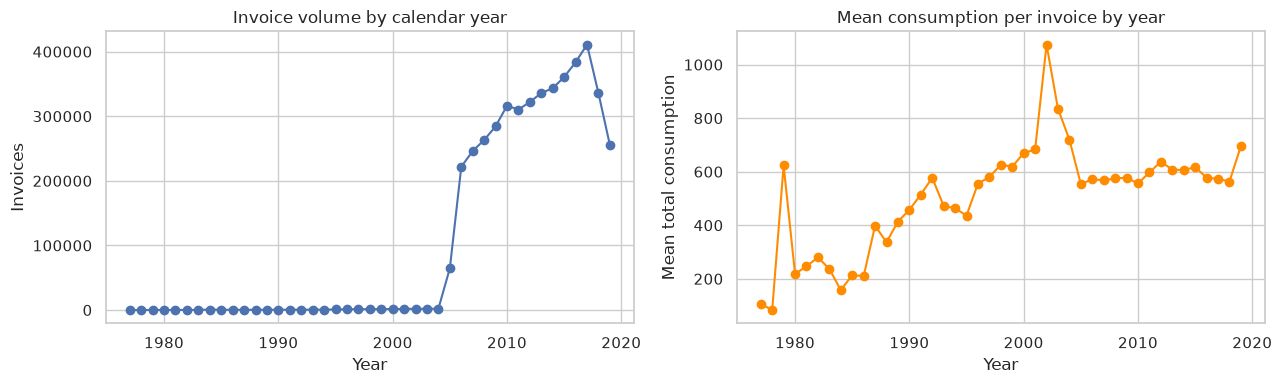

Correlation of reconciliation_gap_abs_mean with target: 0.003 (near zero is expected here -- Pearson correlation is washed out by this heavy-tailed variable's extreme values; the group-mean comparison above is the more trustworthy check)

counter_statue codes outside the expected 0-5 range (see Step 2's counter_status_counts table):


,0
counter_statue,
269375,1
420,1
46,14
618,12
769,6
A,13


Total rows with a genuinely invalid counter_statue code: 47 of 4,476,749 (0.0010%).


In [147]:
def audit_meter_reconciliation(path, chunk_size=250_000, months_number_max_plausible=36, large_mismatch_threshold=10):
    """Check whether new_index - old_index reconciles with reported consumption
    (consommation_level_1..4), and flag months_number values beyond any plausible
    billing period. Also tracks invoice volume/consumption by calendar year to
    check for cohort or recording-practice effects."""
    client_partials = []
    year_partials = []
    months_outlier_rows = 0
    months_max_seen = 0
    total_rows = 0

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "old_index", "new_index", "months_number", *CONSUMPTION_COLUMNS]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        total_rows += len(chunk)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["reconciliation_gap_abs"] = (chunk["index_delta"] - chunk["total_consumption"]).abs()
        chunk["invoice_year"] = chunk["invoice_date"].dt.year
        chunk["is_months_outlier"] = chunk["months_number"] > months_number_max_plausible

        months_outlier_rows += int(chunk["is_months_outlier"].sum())
        months_max_seen = max(months_max_seen, int(chunk["months_number"].max()))

        client_grouped = chunk.groupby("client_id", observed=True).agg(
            reconciliation_gap_abs_sum=("reconciliation_gap_abs", "sum"),
            reconciliation_gap_abs_max=("reconciliation_gap_abs", "max"),
            row_count=("reconciliation_gap_abs", "size"),
            large_mismatch_count=("reconciliation_gap_abs", lambda s: int((s > large_mismatch_threshold).sum())),
            months_outlier_count=("is_months_outlier", "sum"),
        )
        client_partials.append(client_grouped.reset_index())

        year_grouped = chunk.groupby("invoice_year", observed=True).agg(
            invoice_count=("total_consumption", "size"),
            total_consumption_sum=("total_consumption", "sum"),
            zero_consumption_count=("total_consumption", lambda s: int((s == 0).sum())),
        )
        year_partials.append(year_grouped.reset_index())

    client_partial = pd.concat(client_partials, ignore_index=True)
    client_recon = client_partial.groupby("client_id", as_index=False).agg(
        reconciliation_gap_abs_sum=("reconciliation_gap_abs_sum", "sum"),
        reconciliation_gap_abs_max=("reconciliation_gap_abs_max", "max"),
        row_count=("row_count", "sum"),
        large_mismatch_count=("large_mismatch_count", "sum"),
        months_outlier_count=("months_outlier_count", "sum"),
    )
    client_recon["reconciliation_gap_abs_mean"] = client_recon["reconciliation_gap_abs_sum"] / client_recon["row_count"]

    year_partial = pd.concat(year_partials, ignore_index=True)
    year_trend = year_partial.groupby("invoice_year", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
    )
    year_trend["mean_consumption_per_invoice"] = year_trend["total_consumption_sum"] / year_trend["invoice_count"]
    year_trend["zero_consumption_rate"] = year_trend["zero_consumption_count"] / year_trend["invoice_count"]

    audit = {
        "total_rows": total_rows,
        "months_outlier_rows": months_outlier_rows,
        "months_outlier_share": months_outlier_rows / total_rows,
        "months_max_seen": months_max_seen,
    }
    return client_recon, year_trend, audit


meter_recon, year_trend, meter_audit = audit_meter_reconciliation(PARQUET_DIR / "invoice_train.parquet", chunk_size=CHUNK_SIZE)

print(
    f"months_number outliers: {meter_audit['months_outlier_rows']:,} of {meter_audit['total_rows']:,} rows "
    f"({meter_audit['months_outlier_share']:.4%}); largest value seen: {meter_audit['months_max_seen']:,}"
)
print(f"Clients with at least one large index/consumption mismatch (>10 units): "
      f"{(meter_recon['large_mismatch_count'] > 0).sum():,} of {len(meter_recon):,}")

# Add the new features safely if this cell is run more than once.
reconciliation_feature_columns = [column for column in meter_recon.columns if column != "client_id"]
client_features = client_features.drop(columns=reconciliation_feature_columns, errors="ignore").merge(
    meter_recon, on="client_id", how="left", validate="one_to_one"
)

recon_summary = client_features.groupby("target").agg(
    clients=("client_id", "size"),
    reconciliation_gap_abs_mean=("reconciliation_gap_abs_mean", "mean"),
    reconciliation_gap_abs_median=("reconciliation_gap_abs_mean", "median"),
    share_with_large_mismatch=("large_mismatch_count", lambda s: (s > 0).mean()),
    share_with_months_outlier=("months_outlier_count", lambda s: (s > 0).mean()),
)
display(recon_summary)

display(year_trend)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(year_trend["invoice_year"], year_trend["invoice_count"], marker="o")
axes[0].set(title="Invoice volume by calendar year", xlabel="Year", ylabel="Invoices")
axes[1].plot(year_trend["invoice_year"], year_trend["mean_consumption_per_invoice"], marker="o", color="darkorange")
axes[1].set(title="Mean consumption per invoice by year", xlabel="Year", ylabel="Mean total consumption")
plt.tight_layout()
plt.show()

# Single-number correlation check, not a second full heatmap (Step 3 already has one).
reconciliation_correlation = client_features[["reconciliation_gap_abs_mean", "target"]].corr().iloc[0, 1]
print(f"Correlation of reconciliation_gap_abs_mean with target: {reconciliation_correlation:.3f} "
      "(near zero is expected here -- Pearson correlation is washed out by this heavy-tailed "
      "variable's extreme values; the group-mean comparison above is the more trustworthy check)")

# Does the counter_statue dirty-code finding show up in the counts already printed in Step 2?
print("\ncounter_statue codes outside the expected 0-5 range (see Step 2's counter_status_counts table):")
dirty_codes = invoice_audit["counter_status_counts"].loc[
    ~invoice_audit["counter_status_counts"].index.isin(["0", "1", "2", "3", "4", "5"])
]
display(dirty_codes.to_frame())
print(f"Total rows with a genuinely invalid counter_statue code: {dirty_codes.sum():,} of "
      f"{invoice_audit['invoice_rows']:,} ({dirty_codes.sum() / invoice_audit['invoice_rows']:.4%}).")

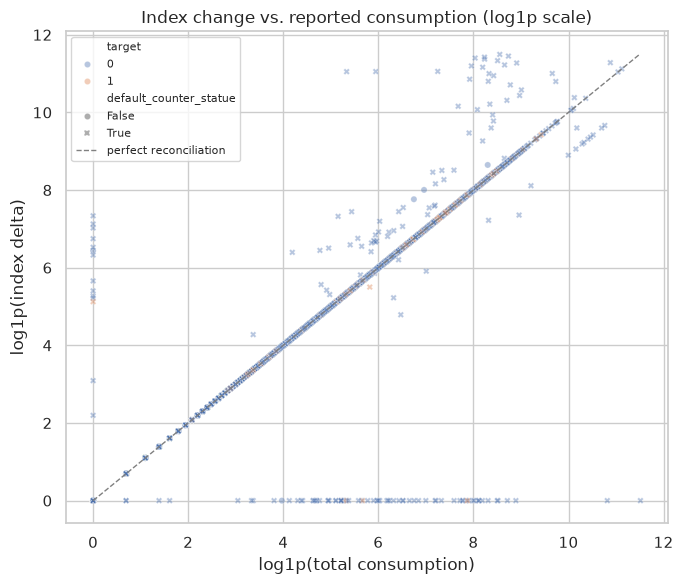

In this sample, 0.5% of invoices have an index/consumption gap larger than 10 units.


In [148]:
row_group_indices = sorted(set([0, max(invoice_parquet.num_row_groups // 2, 0), invoice_parquet.num_row_groups - 1]))
scatter_columns = ["client_id", "old_index", "new_index", *CONSUMPTION_COLUMNS, "counter_statue"]
scatter_frames = []
for row_group in row_group_indices:
    row_group_df = invoice_parquet.read_row_group(row_group, columns=scatter_columns).to_pandas()
    scatter_frames.append(row_group_df.sample(n=min(15_000, len(row_group_df)), random_state=RSEED))

scatter_sample = pd.concat(scatter_frames, ignore_index=True)
scatter_sample["client_id"] = scatter_sample["client_id"].astype("string")
scatter_sample["counter_statue"] = scatter_sample["counter_statue"].astype("string")
scatter_sample["total_consumption"] = scatter_sample[CONSUMPTION_COLUMNS].sum(axis=1)
scatter_sample["index_delta"] = scatter_sample["new_index"] - scatter_sample["old_index"]
scatter_sample = scatter_sample.merge(client_features[["client_id", "target"]], on="client_id", how="inner")
scatter_sample["log1p_index_delta"] = np.log1p(scatter_sample["index_delta"].clip(lower=0))
scatter_sample["log1p_total_consumption"] = np.log1p(scatter_sample["total_consumption"].clip(lower=0))
scatter_sample["default_counter_statue"] = scatter_sample["counter_statue"].eq("0")

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=scatter_sample, x="log1p_total_consumption", y="log1p_index_delta",
    hue="target", style="default_counter_statue", alpha=0.4, s=20, ax=ax,
)
axis_max = scatter_sample[["log1p_total_consumption", "log1p_index_delta"]].to_numpy().max()
ax.plot([0, axis_max], [0, axis_max], color="grey", linestyle="--", linewidth=1, label="perfect reconciliation")
ax.set(title="Index change vs. reported consumption (log1p scale)",
       xlabel="log1p(total consumption)", ylabel="log1p(index delta)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

mismatch_share = ((scatter_sample["index_delta"] - scatter_sample["total_consumption"]).abs() > 10).mean()
print(f"In this sample, {mismatch_share:.1%} of invoices have an index/consumption gap larger than 10 units.")

### Step 6 result

- The reconciliation gap is a candidate association: mean absolute difference between the index change and summed consumption is **75.4 for non-fraud clients versus 118.5 for fraud clients**. The *median* gap is 0 for both groups, so this is driven by a subset with large values, not a uniform shift. `large_mismatch_count` is less sensitive to extreme gap magnitude, but its current `>10` threshold is unvalidated and its count grows with invoice exposure. Domain validation and a mismatch rate should be considered before calling this a billing error.
- Its correlation with `target` looks close to zero on its own — this is expected for a heavy-tailed variable with a handful of extreme values; Pearson correlation is not a reliable way to judge whether a skewed feature carries signal. The group-mean comparison above is the more trustworthy check.
- Clearly implausible `months_number` values (over 36 months) affect only about **0.04%** of rows, but can be extremely large. We leave all month-based features out of the first baseline rather than treating these values as normal billing periods.
- `counter_statue` contains a small number of invalid-looking codes. It is not a baseline input, so this is not a blocker for the first model.
- Invoice volume changes substantially over calendar years. We therefore avoid using raw calendar dates as baseline inputs, because they could capture differences in data collection rather than client behaviour.

## Step 7 — Could `reading_remarque` or `counter_statue` leak the outcome of an investigation?

`reading_remarque` is a note written during a physical site visit. If a visit or note happens because fraud is already suspected, it may describe the investigation rather than behaviour we could know before choosing a client to inspect. `counter_statue` could have the same problem.

We compare each client's last recorded invoice with its earlier invoices. If the unusual values mostly appear at the end of a relationship, they may contain information that would not be available when making an earlier fraud decision.

In [149]:
def audit_last_invoice_leakage(path, last_invoice_lookup, target_lookup, chunk_size=250_000):
    """Compare reading_remarque/counter_statue on each client's LAST invoice against
    their earlier invoices, split by target. Only clients present in target_lookup
    (i.e. client_features) are counted, consistent with the rest of this notebook."""
    counts = {}

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "reading_remarque", "counter_statue"]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")

        chunk["target"] = chunk["client_id"].map(target_lookup)
        chunk = chunk.dropna(subset=["target"])
        chunk["last_invoice_date"] = chunk["client_id"].map(last_invoice_lookup)
        chunk["is_last_invoice"] = chunk["invoice_date"].eq(chunk["last_invoice_date"])

        for column in ["reading_remarque", "counter_statue"]:
            grouped = chunk.groupby(["is_last_invoice", "target", column], observed=True).size()
            for (is_last, target, code), row_count in grouped.items():
                key = (column, bool(is_last), int(target), code)
                counts[key] = counts.get(key, 0) + int(row_count)

    result = pd.Series(counts)
    result.index = pd.MultiIndex.from_tuples(result.index, names=["column", "is_last_invoice", "target", "code"])
    return result.rename("rows").reset_index()


last_invoice_lookup = client_features.set_index("client_id")["last_invoice"]
target_lookup = client_features.set_index("client_id")["target"]

leakage_counts = audit_last_invoice_leakage(
    PARQUET_DIR / "invoice_train.parquet", last_invoice_lookup, target_lookup, chunk_size=CHUNK_SIZE
)

leakage_rows = []
for column in ["reading_remarque", "counter_statue"]:
    sub = leakage_counts.query("column == @column")
    modal_code = sub.groupby("code")["rows"].sum().idxmax()
    flagged = sub.assign(is_flagged=sub["code"].ne(modal_code))
    flagged_sum = flagged[flagged["is_flagged"]].groupby(["is_last_invoice", "target"])["rows"].sum()
    total_sum = flagged.groupby(["is_last_invoice", "target"])["rows"].sum()
    rate = (flagged_sum / total_sum).rename("non_modal_code_rate").reset_index()
    rate["column"] = column
    rate["modal_code"] = modal_code
    leakage_rows.append(rate)

leakage_summary = pd.concat(leakage_rows, ignore_index=True)
leakage_pivot = leakage_summary.pivot_table(
    index=["column", "modal_code"], columns=["target", "is_last_invoice"], values="non_modal_code_rate"
)
display(leakage_pivot)

for column in ["reading_remarque", "counter_statue"]:
    rates = leakage_summary.query("column == @column").set_index(["target", "is_last_invoice"])["non_modal_code_rate"]
    fraud_last = rates.get((1, True), float("nan"))
    fraud_earlier = rates.get((1, False), float("nan"))
    honest_last = rates.get((0, True), float("nan"))
    honest_earlier = rates.get((0, False), float("nan"))
    print(
        f"{column}: fraud clients' LAST invoice non-modal-code rate = {fraud_last:.1%} "
        f"(their earlier invoices: {fraud_earlier:.1%}; non-fraud clients' last invoice: {honest_last:.1%}, "
        f"earlier: {honest_earlier:.1%})"
    )

target                              0                   1          
is_last_invoice                 False     True      False     True 
column           modal_code                                        
counter_statue   0           0.022281  0.011438  0.022799  0.002671
reading_remarque 6           0.490963  0.713099  0.503498  0.795002

reading_remarque: fraud clients' LAST invoice non-modal-code rate = 79.5% (their earlier invoices: 50.3%; non-fraud clients' last invoice: 71.3%, earlier: 49.1%)
counter_statue: fraud clients' LAST invoice non-modal-code rate = 0.3% (their earlier invoices: 2.3%; non-fraud clients' last invoice: 1.1%, earlier: 2.2%)


### Step 7 result

- `reading_remarque` shifts toward unusual codes at a client's *last* invoice for **everyone**, not just fraud clients: non-fraud clients go from 49.1% (earlier invoices) to 71.3% (last invoice); fraud clients go from 50.3% to **79.5%**. The shift is somewhat larger for fraud clients, but it is not exclusive to them—this may be a general end-of-relationship recording pattern rather than fraud-specific leakage alone.
- `counter_statue` moves in the *opposite* direction — the unusual-status rate *drops* at the last invoice for both groups, and drops further for fraud clients specifically (2.3%→0.3%, versus 2.2%→1.1% for non-fraud).
- Whatever the mechanism, these fields change near the end of a client's recorded relationship. We do not use `reading_remarque` or `counter_statue` in the baseline because they could contain information from a later investigation or account event.

## Step 8 — Strong categorical patterns

`client_catg`, `disrict`, and `region` are category codes, even though they contain numbers. This step compares their fraud rates using only `client_features`. It includes group sizes because a high rate from a small group is less reliable than the same rate from a large group.

The dashed line in each chart is the overall fraud rate in all labelled client data. A bar above it identifies a group with more observed fraud; it does not prove that the category or region causes fraud.

Fraud rate by client_catg:


,client_catg,clients,fraud_cases,fraud_rate,relative_to_average
2,51,1678,283,0.168653,3.020265
0,11,131494,7191,0.054687,0.979341
1,12,2321,92,0.039638,0.709844


Fraud rate by disrict:


,disrict,clients,fraud_cases,fraud_rate,relative_to_average
3,69,34231,2447,0.071485,1.280162
2,63,28987,1891,0.065236,1.168258
1,62,40353,2083,0.051619,0.924409
0,60,31922,1145,0.035869,0.642341


Fraud rate by region:


,region,clients,fraud_cases,fraud_rate,relative_to_average
1,103,8964,923,0.102967,1.843955
22,372,644,65,0.100932,1.807499
18,311,12406,998,0.080445,1.440619
4,106,706,53,0.075071,1.344379
15,308,841,61,0.072533,1.298926
21,371,2065,148,0.071671,1.283489
20,313,2076,147,0.070809,1.268062
23,379,583,39,0.066895,1.197972
11,304,3828,256,0.066876,1.197619
5,107,9998,658,0.065813,1.178591


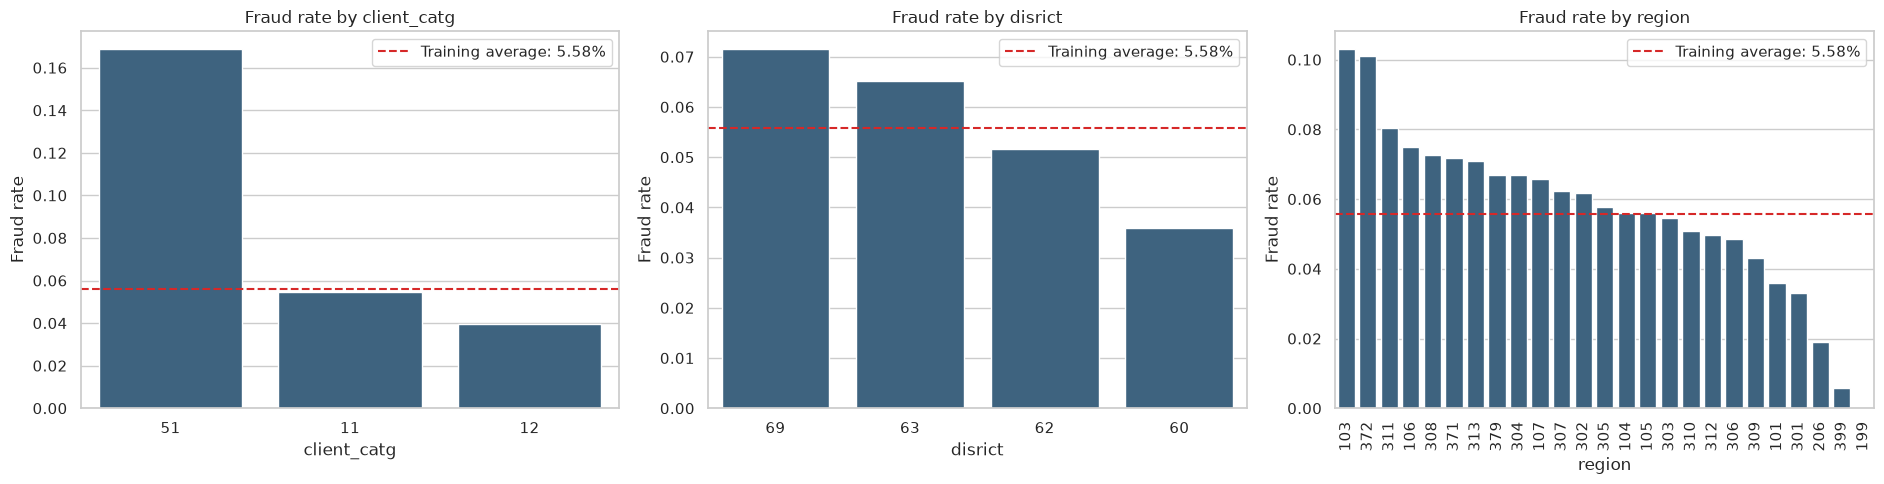

In [150]:
categorical_features = ["client_catg", "disrict", "region"]
categorical_tables = {}
overall_fraud_rate = client_features["target"].mean()

for feature in categorical_features:
    feature_table = (
        client_features.groupby(feature)["target"]
        .agg(clients="size", fraud_cases="sum", fraud_rate="mean")
        .reset_index()
        .sort_values("fraud_rate", ascending=False)
    )
    feature_table["relative_to_average"] = feature_table["fraud_rate"] / overall_fraud_rate
    categorical_tables[feature] = feature_table
    print(f"Fraud rate by {feature}:")
    display(feature_table)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for axis, feature in zip(axes, categorical_features):
    plot_table = categorical_tables[feature].sort_values("fraud_rate", ascending=False)
    plot_table[feature] = plot_table[feature].astype("string")
    sns.barplot(data=plot_table, x=feature, y="fraud_rate", color="#33658A", ax=axis)
    axis.axhline(
        overall_fraud_rate, color="#D62828", linestyle="--",
        label=f"Training average: {overall_fraud_rate:.2%}",
    )
    axis.set(title=f"Fraud rate by {feature}", xlabel=feature, ylabel="Fraud rate")
    axis.tick_params(axis="x", rotation=90 if feature == "region" else 0)
    axis.legend()
fig.tight_layout()
plt.show()

### Step 8 result

- `client_catg` is a strong segment: category **51 has 16.87% fraud**, compared with **5.47%** for category 11 and **3.96%** for category 12. Category 51 has 1,678 labelled clients, so the difference is not based on only a handful of records.
- Geography also contains a pattern. District 69 has **7.15% fraud**, while district 60 has **3.59%**. Region 103 has **10.30% fraud** across 8,964 labelled clients. Region 372 is also high at **10.09%**, but it has only 644 clients, so its result is less stable.
- Treat `client_catg`, `disrict`, and `region` as categorical features and one-hot encode them. Do not pass their numeric codes to the model as continuous numbers. All three are included in the first baseline.
- These fields describe associations, not causes. Geographic performance should be checked during error analysis because the labels may reflect previous inspection activity or regional operating differences.

## Final EDA conclusion — what moves into the baseline?

The EDA started with invoice rows and created one client-level table. The first baseline will use **15 predictor fields**: 3 original client categories and 12 features created from invoice history.

### Final decisions

- Keep all client and invoice rows. We do not delete the 11 duplicate-looking rows, backward readings, or clients with unreliable creation dates.
- Use a small, explicit feature list instead of sending every aggregate into the first model.
- Exclude identifiers, the target, unreliable dates, and fields that may contain information from a later visit or account event.
- Treat `client_catg`, `disrict`, and `region` as categories. Their numeric codes are labels, not quantities.
- Do not drop a feature only because it has low correlation with `target`. The heatmap measures a simple linear relationship and does not capture every useful pattern.
- Create one complete df_training table after there is one row per client and the 15 inputs have been selected. The modelling notebook owns any evaluation split.

### The 15 baseline inputs

| Feature | Source | What it represents and why we keep it |
|---|---|---|
| `invoice_count` | Created from `invoice_train` | Number of invoices. It has a strong EDA association with fraud, but may also reflect how long a client was observed. |
| `active_days` | Created from first and last invoice dates | Length of recorded invoice history without using the unreliable account-creation date. |
| `mean_consumption` | Created from consumption levels 1–4 | Typical consumption per invoice; more comparable than total consumption. |
| `zero_consumption_rate` | Created from invoice rows | Share of invoices with zero consumption; more comparable than a raw count. |
| `elec_share` | Created from `counter_type` | Share of invoices recorded as electricity rather than gas. |
| `mean_invoice_gap_days` | Created from consecutive invoice dates | Typical spacing between invoices. For clients with fewer than two invoices, 0 means no measurable gap. |
| `backwards_index_rate` | Created from `new_index − old_index` | Share of invoices with a backward index. This may represent resets or corrections as well as unusual behaviour. |
| `meter_count` | Created from `counter_number` | Number of recorded meter identifiers connected to the client. An identifier is not independently confirmed to be one physical meter. |
| `mean_monthly_submission_index_delta` | Created from consecutive readings for the same meter | Average meter-reading change adjusted to a monthly interval, so different invoice gaps are more comparable. |
| `backward_submission_rate` | Created from consecutive readings for the same meter | Share of usable meter transitions that move backwards. |
| `large_mismatch_count` | Created from meter change versus billed consumption | Number of invoice mismatches above the current threshold of 10. The threshold still needs domain validation and the count is affected by invoice volume. |
| `reconciliation_gap_abs_mean` | Created from meter change versus billed consumption | Average absolute difference between the meter change and billed consumption. It is heavy-tailed, so large values need attention during error analysis. |
| `client_catg` | Original `client_train` field | Customer category; category 51 has a clearly higher observed fraud rate. |
| `disrict` | Original `client_train` field | District category; fraud rates differ between districts. |
| `region` | Original `client_train` field | Region category; fraud rates differ between regions. |

The category columns remain as category codes in `selected_features`. The modelling step must encode them as categories before fitting logistic regression; this EDA notebook does not create one-hot columns.

### Missing values created during feature engineering

The two source tables contain no missing cells, but feature engineering creates missing values for clients without a usable positive-day transition between readings:

- `mean_monthly_submission_index_delta`: **5,333 missing values**
- `backward_submission_rate`: **5,333 missing values**

The EDA does **not** fill these values. They must be handled explicitly before fitting a model that cannot accept missing values. A missing value here means “no usable transition was available,” not “the source value was forgotten.”

### Do not use as model inputs

| Field | Decision |
|---|---|
| `client_id` | Keep for joins and prediction output, but do not use it to predict fraud. |
| `target` | Keep for training and evaluation; it is the value being predicted. |
| `creation_date` | Exclude because it is later than the first invoice for 8,748 clients. |
| `customer_tenure_days_at_last_invoice` | Exclude because it inherits the unreliable creation-date problem and is negative for 397 clients. |
| `first_invoice`, `last_invoice` | Exclude the raw dates; use `active_days` instead. |
| `reading_remarque`, `counter_statue` | Do not create baseline inputs from them because their values change near the end of the recorded client relationship and may contain later-event information. |

### Leave out of the first baseline

These fields are not permanently deleted. They remain available for later modelling or error analysis.

| Leave out initially | Reason |
|---|---|
| Total, maximum, and raw count versions of selected features | Prefer means, rates, or the smaller selected set so clients with more invoices do not automatically look more extreme. |
| `backwards_index_count` and `backward_submission_count` | Use their rates so clients with different history lengths are more comparable. |
| `invoice_gap_count` and `submission_transition_count` | They mostly repeat the amount of available history. |
| `max_invoice_gap_days` and `total_consumption_max` | Maximum values are sensitive to individual extreme invoices. |
| Alternative meter-sequence summaries | Start with `mean_monthly_submission_index_delta` and `backward_submission_rate`; reconsider the alternatives during error analysis. |
| All `months_number`-derived features | Extremely invalid values exist and these fields are not needed for the first baseline. |
| `invoice_frequency_per_year` and `invoice_count_group` | They overlap with `invoice_count` and `active_days`; the grouped field was created for EDA presentation. |
| Reconciliation sums, maxima, and audit counts | Start with the mismatch count and mean absolute gap, which are easier to explain. |

> **Handoff to modelling:** `df_training` contains `client_id`, `target`, and the 15 predictors for every labelled client. The modelling notebook can create its own client-level evaluation split from this table. The separate Kaggle test data remains unlabelled and cannot be used to calculate local metrics.

In [151]:
# Apply the final EDA decision without deleting columns from the broader client_features.
# These lists are the contract between 01_eda.ipynb and 02_baseline_model.ipynb.
BASELINE_NUMERIC_FEATURES = [
    "invoice_count",
    "active_days",
    "mean_consumption",
    "zero_consumption_rate",
    "elec_share",
    "mean_invoice_gap_days",
    "backwards_index_rate",
    "meter_count",
    "mean_monthly_submission_index_delta",
    "backward_submission_rate",
    "large_mismatch_count",
    "reconciliation_gap_abs_mean",
]

BASELINE_CATEGORICAL_FEATURES = ["client_catg", "disrict", "region"]
BASELINE_FEATURES = BASELINE_NUMERIC_FEATURES + BASELINE_CATEGORICAL_FEATURES
EXPORT_ONLY_COLUMNS = ["client_id", "target"]

EXCLUDED_FROM_MODEL = [
    "client_id", "creation_date", "customer_tenure_days_at_last_invoice",
    "reading_remarque", "counter_statue", "first_invoice", "last_invoice",
    "target",
]

POSTPONED_FEATURES = [
    "total_consumption_sum", "total_consumption_max",
    "index_delta_sum", "index_delta_min", "index_delta_max", "mean_index_delta",
    "zero_consumption_count", "elec_invoice_count", "gaz_invoice_count",
    "backwards_index_count", "invoice_gap_count", "max_invoice_gap_days",
    "months_sum", "valid_billing_invoice_count", "billed_months_sum",
    "index_delta_valid_months_sum", "four_month_bill_count", "mean_months",
    "mean_index_delta_per_billed_month", "mean_billing_months",
    "four_month_bill_rate", "invoice_frequency_per_year", "invoice_count_group",
    "submission_transition_count", "mean_submission_index_delta",
    "median_submission_index_delta", "median_monthly_submission_index_delta",
    "median_submission_gap_days", "backward_submission_count",
    "reconciliation_gap_abs_sum", "reconciliation_gap_abs_max", "row_count",
    "months_outlier_count",
]

missing_selected_features = [column for column in BASELINE_FEATURES if column not in client_features.columns]
if missing_selected_features:
    raise ValueError(
        f"Feature-selection contract failed. Missing from client_features: {missing_selected_features}"
    )

unexpected_selected_columns = sorted(set(BASELINE_FEATURES) & set(EXCLUDED_FROM_MODEL))
if unexpected_selected_columns:
    raise ValueError(f"Unsafe columns selected as predictors: {unexpected_selected_columns}")

classified_columns = set(BASELINE_FEATURES + EXCLUDED_FROM_MODEL + POSTPONED_FEATURES)
unclassified_columns = sorted(set(client_features.columns) - classified_columns)
if unclassified_columns:
    raise ValueError(
        f"Final EDA decision is incomplete. Classify these columns before exporting: "
        f"{unclassified_columns}"
    )

export_columns = EXPORT_ONLY_COLUMNS + BASELINE_FEATURES
selected_features = client_features[export_columns].copy()

feature_contract = pd.DataFrame({
    "feature": BASELINE_FEATURES,
    "type": ["numeric"] * len(BASELINE_NUMERIC_FEATURES)
            + ["categorical"] * len(BASELINE_CATEGORICAL_FEATURES),
    "origin": ["created from invoice_train"] * len(BASELINE_NUMERIC_FEATURES)
              + ["original client_train field"] * len(BASELINE_CATEGORICAL_FEATURES),
})
feature_contract["missing_values"] = [
    int(selected_features[column].isna().sum()) for column in BASELINE_FEATURES
]
print(f"Selected {len(BASELINE_FEATURES)} predictors: "
      f"{len(BASELINE_NUMERIC_FEATURES)} numeric and "
      f"{len(BASELINE_CATEGORICAL_FEATURES)} categorical.")
print(f"Selected feature table shape: {selected_features.shape}")
print(f"All {len(client_features.columns)} EDA columns have a keep, exclude, or postpone decision.")
display(feature_contract)

Selected 15 predictors: 12 numeric and 3 categorical.
Selected feature table shape: (135493, 17)
All 54 EDA columns have a keep, exclude, or postpone decision.


,feature,type,origin,missing_values
0,invoice_count,numeric,created from invoice_train,0
1,active_days,numeric,created from invoice_train,0
2,mean_consumption,numeric,created from invoice_train,0
3,zero_consumption_rate,numeric,created from invoice_train,0
4,elec_share,numeric,created from invoice_train,0
5,mean_invoice_gap_days,numeric,created from invoice_train,0
6,backwards_index_rate,numeric,created from invoice_train,0
7,meter_count,numeric,created from invoice_train,0
8,mean_monthly_submission_index_delta,numeric,created from invoice_train,5333
9,backward_submission_rate,numeric,created from invoice_train,5333


## Step 9 — Create the reusable feature-engineering pipeline

The EDA has now produced one row per labelled client and selected the 15 model inputs. We do not split the data here. The output is the complete df_training.csv table; the modelling notebook can create a client-level evaluation split when it is ready.

The complete sklearn feature_engineering_pipeline has two stages:

1. ClientFeatureBuilder runs aggregate_invoices, aggregate_meter_submissions, and audit_meter_reconciliation on raw client/invoice inputs and selects the 15 agreed features.
2. The preprocessing stage median-imputes the two derived transition features, scales numeric values, and one-hot encodes the three category fields.

For evaluation, fit the pipeline on training data only. For future data, call transform with the raw client and invoice paths. The transformer reruns the same feature-building functions and then applies the transformations learned during fit. It does not refit on future data.

In [152]:
class ClientFeatureBuilder(BaseEstimator, TransformerMixin):
    """Build the selected client features from raw client and invoice inputs.

    The transformer accepts either:
    1. a prepared DataFrame containing the 15 baseline features; or
    2. a dictionary with client_path and invoice_path for raw Parquet data.

    The second form calls the same three feature-building functions used by
    the EDA. This makes the raw-to-model process reusable for future data.
    """

    def __init__(self, feature_columns=None, chunk_size=250_000, as_of_date=None):
        self.feature_columns = feature_columns
        self.chunk_size = chunk_size
        self.as_of_date = as_of_date

    def _selected_columns(self):
        return list(self.feature_columns or BASELINE_FEATURES)

    @staticmethod
    def _load_client(source):
        if isinstance(source, pd.DataFrame):
            frame = source.copy()
        else:
            frame = pd.read_parquet(source)
        frame["client_id"] = frame["client_id"].astype("string")
        return frame

    def _build_from_raw(self, raw_data):
        if not isinstance(raw_data, dict):
            raise TypeError(
                "Raw input must be a dictionary with client_path and invoice_path."
            )
        if "client_path" not in raw_data or "invoice_path" not in raw_data:
            raise KeyError("Raw input needs client_path and invoice_path.")

        client_frame = self._load_client(raw_data["client_path"])
        invoice_path = raw_data["invoice_path"]

        invoice_features, _ = aggregate_invoices(
            invoice_path,
            chunk_size=self.chunk_size,
            as_of_date=self.as_of_date,
        )
        submission_features = aggregate_meter_submissions(
            invoice_path,
            chunk_size=self.chunk_size,
            as_of_date=self.as_of_date,
        )
        reconciliation_features, _, _ = audit_meter_reconciliation(
            invoice_path,
            chunk_size=self.chunk_size,
        )

        client_features = (
            client_frame
            .merge(invoice_features, on="client_id", how="left", validate="one_to_one")
            .merge(submission_features, on="client_id", how="left", validate="one_to_one")
            .merge(reconciliation_features, on="client_id", how="left", validate="one_to_one")
        )
        return client_features

    def _make_features(self, X):
        if isinstance(X, pd.DataFrame):
            client_features = X.copy()
        else:
            client_features = self._build_from_raw(X)

        selected_columns = self._selected_columns()
        missing_columns = [
            column for column in selected_columns if column not in client_features.columns
        ]
        if missing_columns:
            raise ValueError(
                f"Feature builder is missing required columns: {missing_columns}"
            )
        return client_features[selected_columns].copy()

    def fit(self, X, y=None):
        prepared = self._make_features(X)
        self.feature_names_in_ = prepared.columns.to_numpy()
        return self

    def transform(self, X):
        return self._make_features(X)


In [153]:
# Keep one complete labelled table for modelling.
# There is no train/test split in the EDA notebook. The model notebook decides
# how to split this table for evaluation.
df_training = selected_features.copy()

# This is the complete sklearn pipeline:
#   raw client/invoice data
#       -> ClientFeatureBuilder (all three EDA feature builders)
#       -> select the 15 baseline inputs
#       -> median-impute derived transition features
#       -> standardise numeric values
#       -> one-hot encode category codes
#
# Passing df_training to fit uses the prepared table from this notebook.
# Passing a dictionary with client_path and invoice_path to transform reruns
# the same feature-building functions for future data.
numeric_preparation = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

feature_engineering_pipeline = Pipeline([
    ("build_client_features", ClientFeatureBuilder(
        feature_columns=BASELINE_FEATURES,
        chunk_size=CHUNK_SIZE,
        as_of_date=AS_OF_DATE,
    )),
    ("prepare_inputs", ColumnTransformer([
        ("numeric", numeric_preparation, BASELINE_NUMERIC_FEATURES),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), BASELINE_CATEGORICAL_FEATURES),
    ])),
])

print("Complete feature-engineering pipeline defined.")
print("It can fit on df_training or transform raw client/invoice paths.")


Complete feature-engineering pipeline defined.
It can fit on df_training or transform raw client/invoice paths.


### Workflow for testing data
!!! **Do not execute this cell until the future Parquet paths exist** !!!

In [154]:
# Example only: transform unlabelled future data with the fitted complete pipeline.
#
# ** Do not execute this cell until the future Parquet paths exist. **
#
# raw_future_data = {
#     "client_path": PARQUET_DIR / "client_test.parquet",
#     "invoice_path": PARQUET_DIR / "invoice_test.parquet",
# }
# X_future = feature_engineering_pipeline.transform(raw_future_data)
#
# X_future is now ready for the fitted fraud model. The pipeline has rerun
# the same invoice feature calculations and preprocessing as for training.

### Save the prepared training data and complete pipeline

Leave saving off while you are still changing the EDA. When the final feature contract and pipeline cell run successfully, set SAVE_TRAINING_ARTIFACTS=true in .env and run the save cell. It saves the complete labelled df_training.csv and a fitted feature_engineering_pipeline.joblib in data/processed.

The CSV contains client_id, target, and the 15 selected predictors. The joblib artifact contains the complete feature pipeline: raw client/invoice aggregation plus model-input preparation. For evaluation, fit an equivalent pipeline inside cross-validation on the modelling training folds. For a final model trained on all labelled data, fit this pipeline on df_training and reuse it unchanged for future raw client/invoice data.

If you change .env while the kernel is already running, restart the kernel or rerun the imports/configuration cell before running this save cell. The configuration cell prints the .env path and the resolved SAVE_TRAINING_ARTIFACTS value so you can verify the setting.

In [155]:
if SAVE_TRAINING_ARTIFACTS:
    from joblib import dump

    output_dir = DATA_DIR / "processed"
    output_dir.mkdir(parents=True, exist_ok=True)
    training_output_path = output_dir / "df_training.csv"
    pipeline_output_path = output_dir / "feature_engineering_pipeline.joblib"

    # Fit the reusable preprocessing artifact on the complete labelled training
    # table only. Do not use this fitted artifact for unbiased evaluation; fit
    # inside the modelling pipeline for that purpose.
    feature_engineering_pipeline.fit(df_training)
    df_training.to_csv(training_output_path, index=False)
    dump(feature_engineering_pipeline, pipeline_output_path)

    print(f"Saved {len(df_training):,} labelled clients to {training_output_path}")
    print(f"Saved feature-engineering pipeline to {pipeline_output_path}")
else:
    print("Feature saving is disabled. Set SAVE_TRAINING_ARTIFACTS=true in .env when the training feature table and pipeline are ready to save locally.")

Saved 135,493 labelled clients to /home/jovyan/work/week_08/ds-fraud-in-electricity-and-gas/data/processed/df_training.csv
Saved feature-engineering pipeline to /home/jovyan/work/week_08/ds-fraud-in-electricity-and-gas/data/processed/feature_engineering_pipeline.joblib


In [156]:
print("Our saved pipeline")
feature_engineering_pipeline

Our saved pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('build_client_features', ...), ('prepare_inputs', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['invoice_count','active_days','mean_consumption',...,'client_catg', 'disrict','region']"
,feature_columns,"['invoice_count', 'active_days', ...]"
,chunk_size,250000
,as_of_date,None
Name,Type,Value
feature_names_in_,"ndarray[object](15,)","['invoice_count','active_days','mean_consumption',...,'client_catg', 'disrict','region']"
